# Customer Churn — Exploratory Data Analysis
**UK Broadband Division | Data Understanding (CRISP-DM Phase 2)**

---

### Executive Summary

This analysis examines **203K broadband customers** across four data sources (customer records, cease events, call-centre interactions, and daily usage telemetry spanning **Aug 2022 – Sep 2024**) to identify the key drivers of customer churn.

> **Interpretation note:** The cumulative churn rate below (≈65%) counts every customer who *ever* placed a cease order during the 25-month observation window. The **operational monthly churn rate** averages **≈4 %** (range ≈2.5 – 6.1 %, excluding incomplete edge months), which is the metric used in downstream modelling and is more relevant for business planning.

**Headline findings:**

| Metric | Value | Implication |
|--------|-------|-------------|
| Cumulative churn rate | **≈65 %** of customers observed (131 K / 203 K) | High over 25 months; operational monthly rate is ≈4 % |
| Monthly churn rate | **≈4 % avg** (range ≈2.5 – 6.1 %; the 0.1 % extreme low is an incomplete final month) | This is the rate used in predictive modelling |
| #1 correlate | **Tenure** (r = −0.49 with churn) | Partially a measurement artefact — see §7 caveats |
| Loyalty call signal | **77.6 %** churn rate if customer received a loyalty call | ⚠️ Reverse causality — loyalty calls are triggered *by* churn intent (41 % occur on/after cease date) |
| Speed gap | Churned customers get **6.9 %** less than provisioned (mean); median gap is 0 % vs −6.6 % for active | Mean pulled by outliers; median shows active customers over-delivered |
| DD cancellation | DD cancel → **≈85–97 % churn** across all OOC buckets | ⚠️ Potential reverse causality — DD may be cancelled *as part of* the cease process, not as a preceding signal. Timing vs cease date not yet examined |
| Cease processing time | Median **19 days** from placed to completed | Window for save-desk intervention |

> **Recommendation:** A predictive churn model using contract status, call-centre signals, and usage patterns has strong discriminative potential. However, several EDA findings (tenure correlation, loyalty-call rates, DD cancellation rates) contain measurement artefacts or potential reverse causality that must not be taken at face value — see caveats throughout.

---

**Data sources analysed:**

| Source | Records | Description |
|--------|---------|-------------|
| Customer Info | 3.5 M snapshots | Monthly contract, speed, tenure, technology |
| Cease Events | 146 K events (131 K distinct customers) | Churn label, reason, dates |
| Call Centre | 628 K interactions | Call type, talk/hold time |
| Usage Telemetry | 83 M daily records | Download/upload volumes |

---

In [ ]:

import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from churn.data.loader import ingest_raw_tables, get_connection
from churn.config import cfg

# ── Display & style ──
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Colour palette (used throughout) ──
PALETTE = {'Churned': '#E63946', 'Active': '#457B9D'}
ACCENT  = '#1D3557'
WARN    = '#F1A208'
NEUTRAL = '#6B7280'

# ── Churn label helpers (avoids repeating inline ternaries throughout) ──
CHURN_LABEL_MAP: dict[int, str] = {0: 'Active', 1: 'Churned'}
CHURN_VAL_MAP: dict[str, int]   = {'Active': 0, 'Churned': 1}

# ── Sample sizes used for expensive visualisations ──
VIZ_SAMPLE: int  = 5_000   # scatter / pairplot samples
CALL_SAMPLE: int = 50_000  # call-centre sample

# ── Allowlist for table names used in dynamic SQL (prevents injection) ──
_ALLOWED_TABLES: frozenset[str] = frozenset({'customer_info', 'usage', 'calls', 'cease'})


In [2]:

# ── Helper functions ─────────────────────────────────────────────────────────

def save_fig(fig: plt.Figure, name: str) -> None:
    """Save *fig* to the configured figures directory as a high-res PNG."""
    out_dir = cfg.paths.figures_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f'{name}.png', dpi=150, bbox_inches='tight')


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Cramér's V association strength between two categorical series.

    Returns a value in [0, 1]: 0 = no association, 1 = perfect association.
    """
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    return float(np.sqrt(chi2 / (n * min_dim)))


def validated_table(name: str) -> str:
    """Return *name* unchanged after confirming it is in the allowlist.

    Raises ValueError for unknown table names, preventing SQL injection from
    dynamic query construction.
    """
    if name not in _ALLOWED_TABLES:
        raise ValueError(f"Unknown table '{name}'. Allowed: {sorted(_ALLOWED_TABLES)}")
    return name


In [3]:

ingest_raw_tables()
con = get_connection()

tables = ['customer_info', 'usage', 'calls', 'cease']
print('── Data Inventory ──────────────────────────────────────')
for table in tables:
    safe_table = validated_table(table)
    row_count = con.execute(f'SELECT COUNT(*) FROM {safe_table}').fetchone()[0]
    col_count = len(con.execute(f'SELECT * FROM {safe_table} LIMIT 0').description)
    print(f'  {table:<20}  rows: {row_count:>12,}   cols: {col_count:>3}')
print('────────────────────────────────────────────────────────')

# Load only the three small tables into memory as DataFrames.
# usage (83M rows) is intentionally left inside DuckDB and accessed
# exclusively via con.execute("SELECT … FROM usage …") throughout this
# notebook — materialising 83M rows as a DataFrame would exhaust RAM.
customer_info = con.execute('SELECT * FROM customer_info').fetchdf()
cease         = con.execute('SELECT * FROM cease').fetchdf()
calls         = con.execute('SELECT * FROM calls').fetchdf()
print('DataFrames loaded: customer_info, cease, calls.')
print('usage (83M rows) remains in DuckDB — query via con.execute().')


── Data Inventory ──────────────────────────────────────
  customer_info         rows:    3,545,538   cols:  12
  usage                 rows:   83,185,050   cols:   4
  calls                 rows:      628,437   cols:   5
  cease                 rows:      146,363   cols:   5
────────────────────────────────────────────────────────
DataFrames loaded: customer_info, cease, calls.
usage (83M rows) remains in DuckDB — query via con.execute().


## 1. Dataset Overview & Data Quality Snapshot

Before diving into patterns, we establish the shape, completeness, and basic statistical profile of each source.

In [5]:

quality_rows = []
for table in tables:
    safe_table = validated_table(table)
    tbl_quality = con.execute(f"""
        SELECT
            column_name,
            null_percentage        AS pct_null,
            approx_unique          AS n_distinct
        FROM (SUMMARIZE {safe_table})
    """).fetchdf()
    tbl_quality['table'] = table
    quality_rows.append(tbl_quality)

quality = pd.concat(quality_rows, ignore_index=True)
print(f'Total columns across all tables: {len(quality)}')
quality[quality['pct_null'] > 0].sort_values('pct_null', ascending=False).head(20)


Total columns across all tables: 26


,column_name,pct_null,n_distinct,table
5,ooc_days,0.530,6849,customer_info


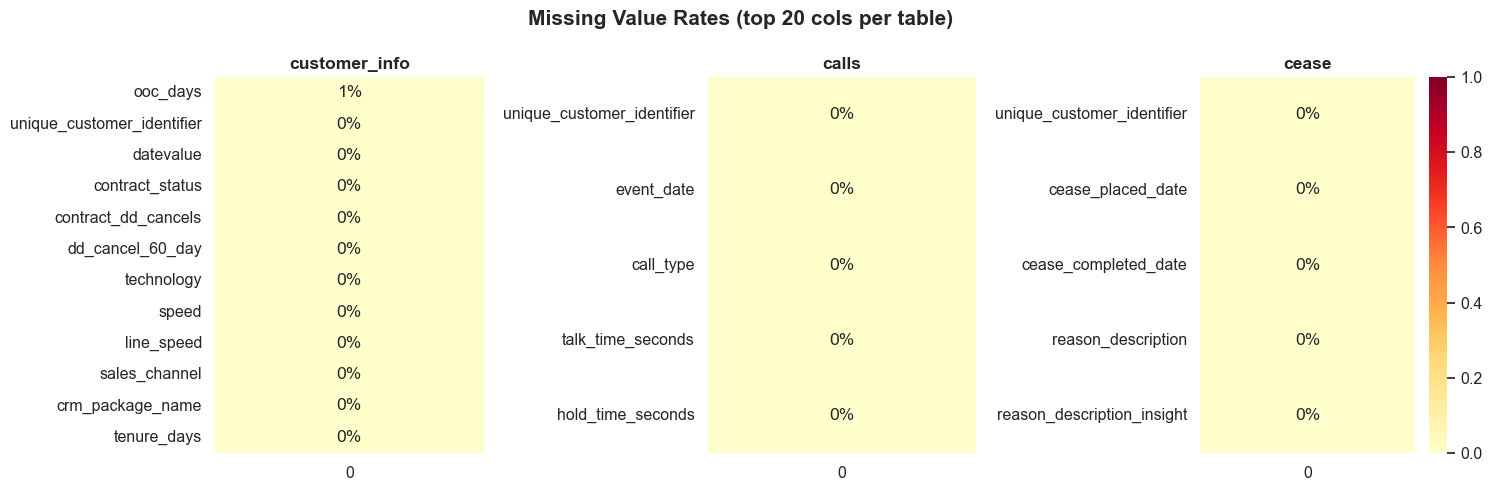

In [6]:

tables_subset = [t for t in tables if t != 'usage']
named_frames = {'customer_info': customer_info, 'cease': cease, 'calls': calls}

fig, axes = plt.subplots(1, len(tables_subset), figsize=(15, 5))
for ax, table_name in zip(axes, tables_subset):
    table_df = named_frames[table_name]
    missing = table_df.isnull().mean().sort_values(ascending=False).head(20)
    sns.heatmap(missing.to_frame(), ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                cbar=(ax is axes[-1]), annot=True, fmt='.0%')
    ax.set_title(table_name, fontweight='bold')

fig.suptitle('Missing Value Rates (top 20 cols per table)', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'eda_missing_heatmap')
plt.show()


## 2. Churn Target — Scale, Reasons & Trends

The cease table defines our churn label. Every customer who placed a cease order is classified as churned. Understanding *why* and *when* customers leave shapes our modelling strategy.

> **Definition clarity:** The churn rate calculated here (≈65 %) is the *cumulative* fraction of distinct customers who placed at least one cease order across the full 25-month observation window. It does **not** represent the monthly or annualised churn rate. The average **monthly churn rate is ≈4 %** (range ≈2.5 – 6.1 %, excluding incomplete edge months), which is the operationally meaningful metric and the rate used in downstream predictive modelling.

Total cease rows: 146,363  |  Distinct churned customers: 130,934  |  Duplicate cease rows: 15,429


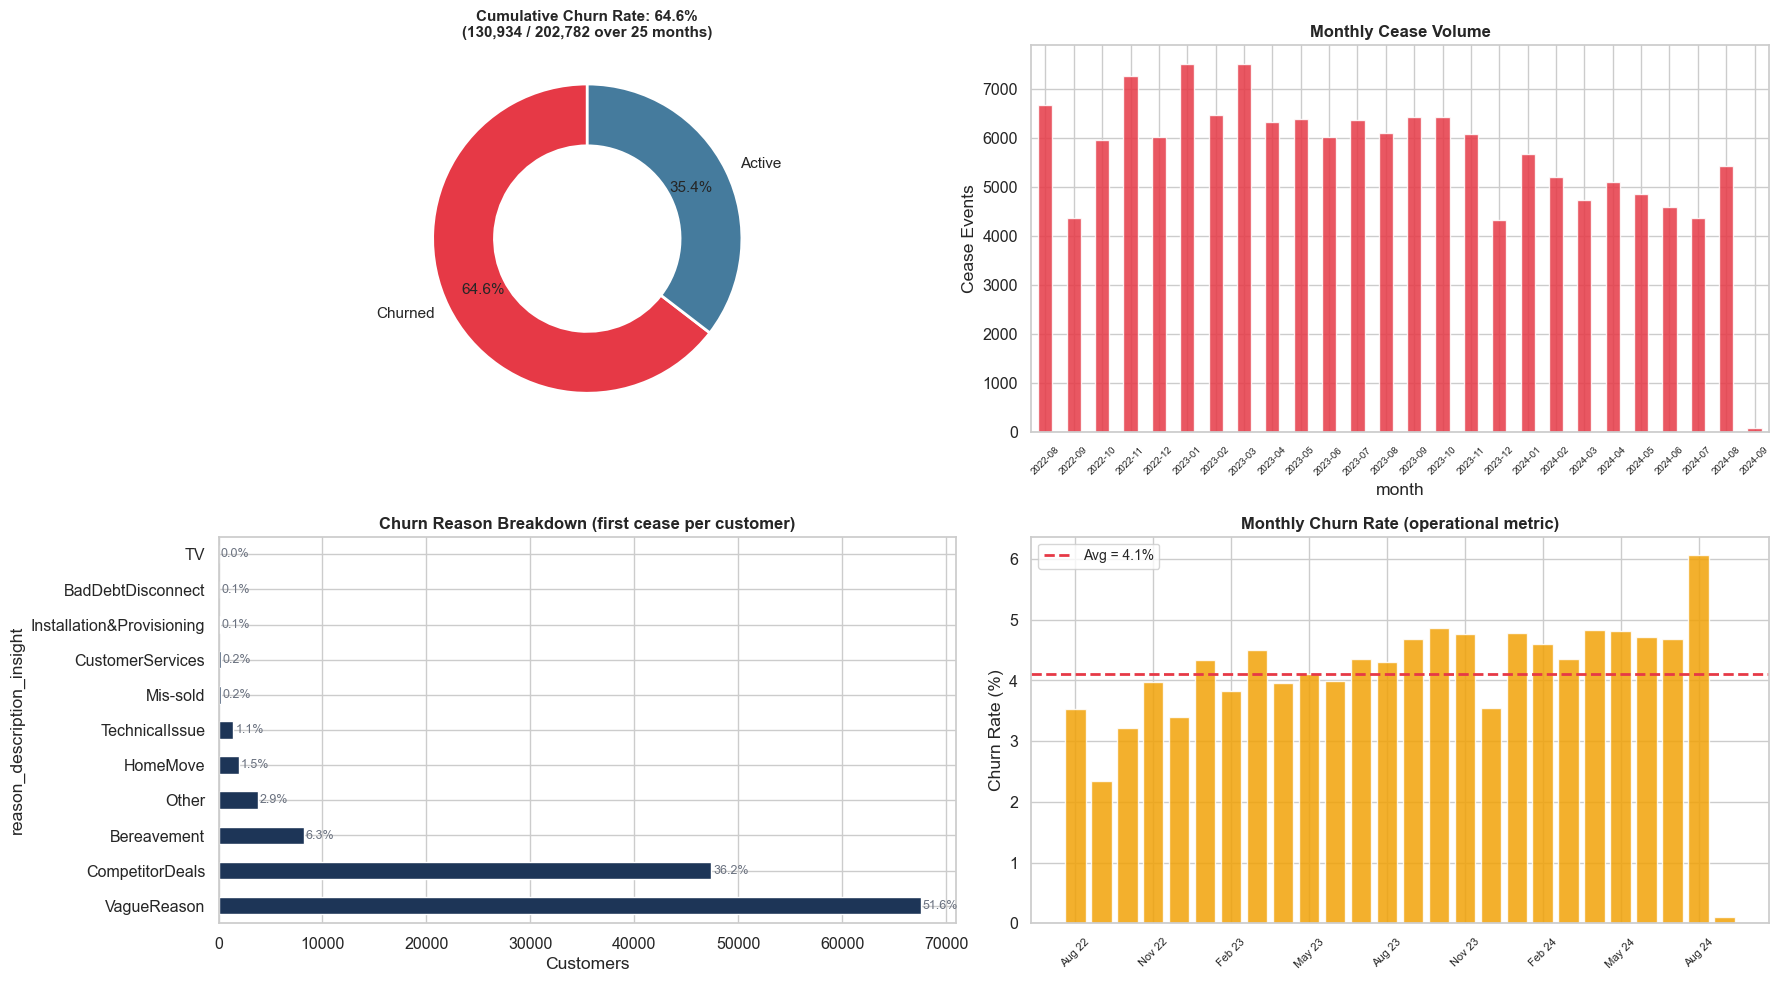

In [7]:

# Churn rate = distinct churned customers / total distinct customers
# NOTE: cease table may contain >1 row per customer (re-contracts, product swaps)
#       so we must count DISTINCT customers, not raw rows.
total_customers = con.execute(
    'SELECT COUNT(DISTINCT unique_customer_identifier) FROM customer_info'
).fetchone()[0]
distinct_churners = con.execute(
    'SELECT COUNT(DISTINCT unique_customer_identifier) FROM cease'
).fetchone()[0]
dup_cease = len(cease) - distinct_churners
churn_rate = distinct_churners / total_customers

print(f'Total cease rows: {len(cease):,}  |  Distinct churned customers: {distinct_churners:,}'
      f'  |  Duplicate cease rows: {dup_cease:,}')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Churn proportion — clean donut (using distinct customers)
sizes = [churn_rate, 1 - churn_rate]
colours = [PALETTE['Churned'], PALETTE['Active']]
wedges, texts, autotexts = axes[0, 0].pie(
    sizes, labels=['Churned', 'Active'], autopct='%1.1f%%', startangle=90,
    colors=colours, textprops={'fontsize': 11}, pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2})
axes[0, 0].set_title(f'Cumulative Churn Rate: {churn_rate:.1%}\n({distinct_churners:,} / {total_customers:,} over 25 months)',
                      fontsize=11, fontweight='bold')

# Monthly cease volume
monthly = (cease
    .assign(month=lambda x: pd.to_datetime(x['cease_placed_date']).dt.to_period('M'))
    .groupby('month').size())
monthly.plot(kind='bar', ax=axes[0, 1], color=PALETTE['Churned'], alpha=0.85, edgecolor='white')
axes[0, 1].set_title('Monthly Cease Volume', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Cease Events')
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=7)

# Reason breakdown — deduplicated to first cease per customer
reason_counts = (cease
    .sort_values('cease_placed_date')
    .drop_duplicates('unique_customer_identifier', keep='first')
    ['reason_description_insight'].value_counts())
reason_counts.plot(kind='barh', ax=axes[1, 0], color=ACCENT, edgecolor='white')
axes[1, 0].set_title('Churn Reason Breakdown (first cease per customer)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Customers')
for idx, (val, name) in enumerate(zip(reason_counts.values, reason_counts.index)):
    axes[1, 0].text(val + 200, idx, f'{val/distinct_churners*100:.1f}%', va='center', fontsize=9, color=NEUTRAL)

# Monthly churn rate — the operationally meaningful metric
monthly_base = con.execute("""
    SELECT datevalue, COUNT(DISTINCT unique_customer_identifier) AS base
    FROM customer_info GROUP BY 1 ORDER BY 1
""").fetchdf()
monthly_cease_agg = con.execute("""
    SELECT DATE_TRUNC('month', cease_placed_date::DATE) AS month,
           COUNT(DISTINCT unique_customer_identifier) AS churners
    FROM cease GROUP BY 1
""").fetchdf()
monthly_rates = monthly_base.merge(
    monthly_cease_agg, left_on='datevalue', right_on='month', how='left')
monthly_rates['churners'] = monthly_rates['churners'].fillna(0)
monthly_rates['churn_pct'] = monthly_rates['churners'] / monthly_rates['base'] * 100

axes[1, 1].bar(range(len(monthly_rates)), monthly_rates['churn_pct'],
               color=WARN, edgecolor='white', alpha=0.85)
axes[1, 1].axhline(monthly_rates['churn_pct'].mean(), color=PALETTE['Churned'],
                    linestyle='--', linewidth=2,
                    label=f'Avg = {monthly_rates["churn_pct"].mean():.1f}%')
axes[1, 1].set_title('Monthly Churn Rate (operational metric)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xticks(range(0, len(monthly_rates), 3))
axes[1, 1].set_xticklabels(monthly_rates['datevalue'].dt.strftime('%b %y').iloc[::3],
                            rotation=45, fontsize=8)
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
save_fig(fig, 'eda_churn_overview')
plt.show()


> **Takeaway:** The cumulative churn rate is **≈65 %** (131 K distinct churners from 203 K customers; 15 K duplicate cease rows excluded). "Vague Reason" (51.6 %) and "Competitor Deals" (36.2 %) dominate cease reasons. Monthly volumes show a declining trend through 2024 — worth investigating whether this reflects improved retention or shrinking base.
>
> ⚠️ **Context:** This 65 % is a cumulative figure over 25 months. The operational **monthly churn rate averages ≈4 %**, which is within the typical UK broadband range. Note that the first and last months of the observation window may have incomplete cease data, producing artificially low rates (the 0.1 % extreme visible on the chart is Sep 2024, almost certainly an incomplete month).
>
> ⚠️ **Voluntary vs involuntary / non-addressable churn:** The cease reasons contain a mix requiring different treatment:
> - **Addressable voluntary** (target for retention): CompetitorDeals (36.2 %), TechnicalIssue (1.1 %), Mis-sold (0.2 %)
> - **Non-addressable / life-event**: Bereavement (6.3 %), HomeMove (1.5 %) — no reasonable save-desk intervention
> - **Involuntary**: BadDebtDisconnect (0.1 %) — driven by financial distress, not dissatisfaction
> - **Unclassified**: VagueReason (51.6 %) — severely limits actionability; improving reason coding should be a priority
>
> These groupings have fundamentally different drivers, intervention opportunities, and cost profiles. Downstream modelling should either separate addressable from non-addressable churn or at minimum control for churn type. The **addressable churn pool** is materially smaller than the headline 131 K: Bereavement alone removes ≈8.2 K customers from the intervention-eligible population.

---

## 3. Customer Profile — Contract, Technology & Service

Understanding the composition of the customer base helps contextualise churn drivers.

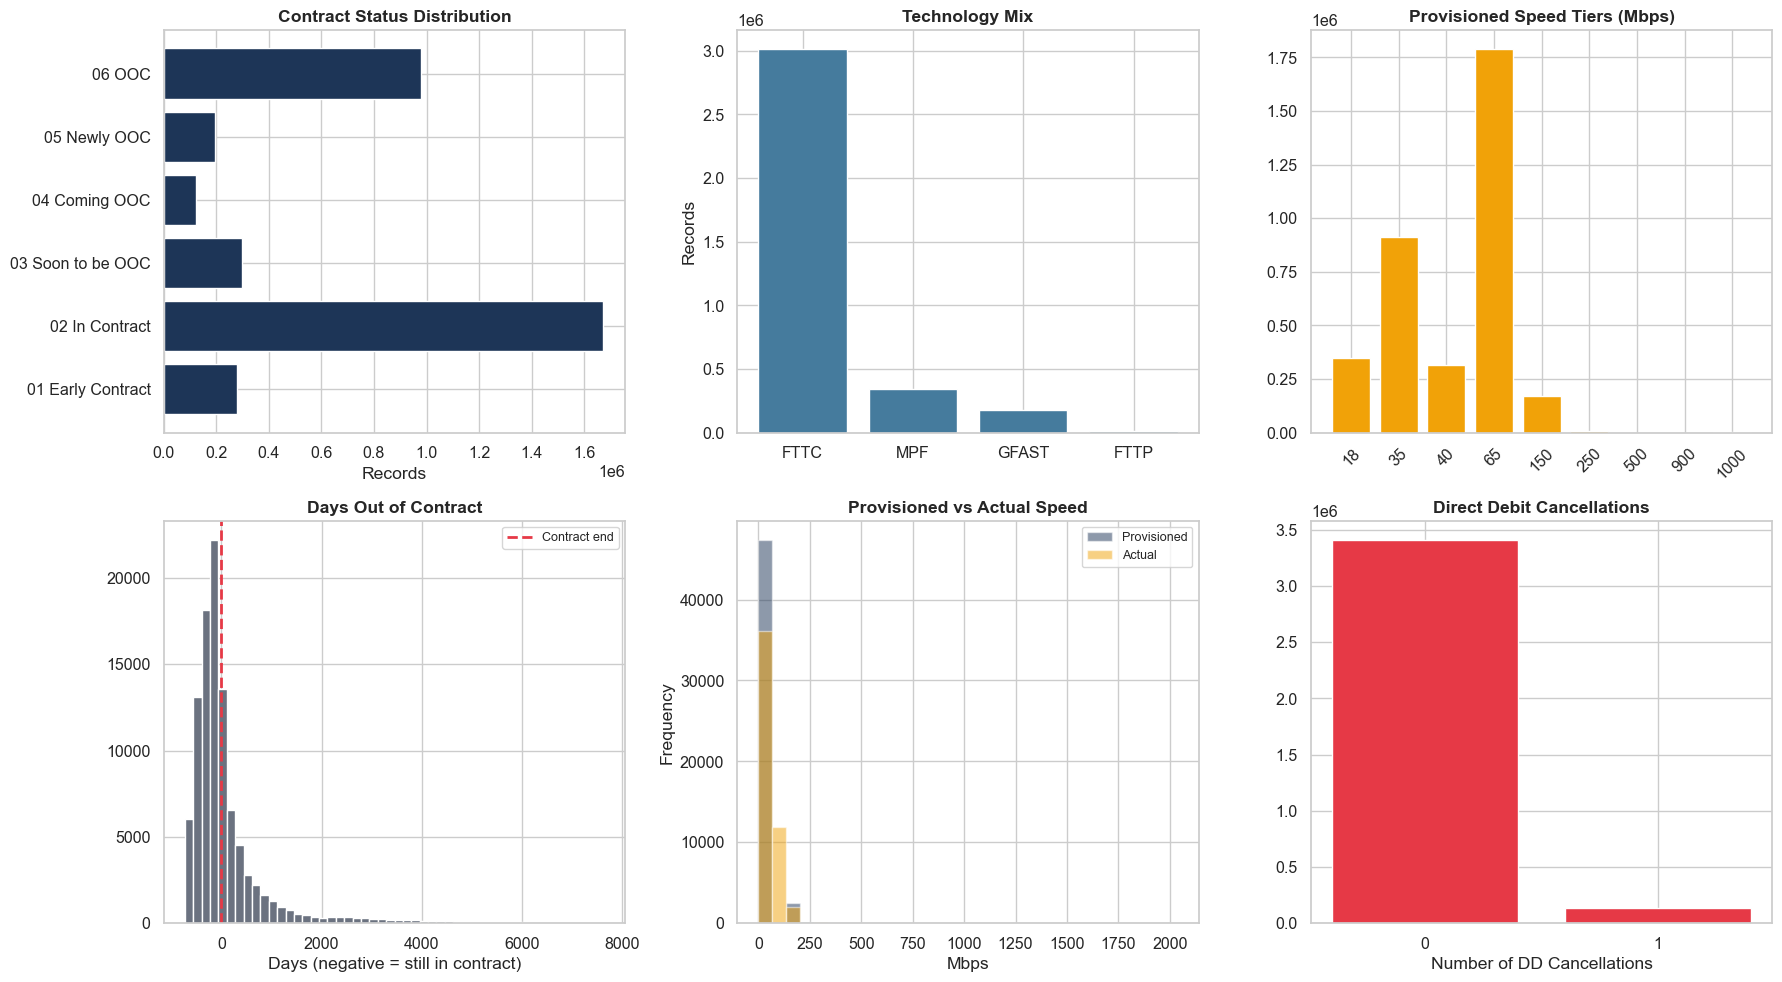

In [8]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Contract status
cs = con.execute("SELECT contract_status, COUNT(*) AS n FROM customer_info GROUP BY 1 ORDER BY 1").fetchdf()
axes[0, 0].barh(cs['contract_status'], cs['n'], color=ACCENT, edgecolor='white')
axes[0, 0].set_title('Contract Status Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Records')

# Technology
tech = con.execute("SELECT technology, COUNT(*) AS n FROM customer_info GROUP BY 1 ORDER BY 2 DESC").fetchdf()
axes[0, 1].bar(tech['technology'], tech['n'], color=PALETTE['Active'], edgecolor='white')
axes[0, 1].set_title('Technology Mix', fontweight='bold')
axes[0, 1].set_ylabel('Records')

# Speed tier
spd = con.execute("SELECT speed, COUNT(*) AS n FROM customer_info GROUP BY 1 ORDER BY 1 LIMIT 15").fetchdf()
axes[0, 2].bar(spd['speed'].astype(str), spd['n'], color=WARN, edgecolor='white')
axes[0, 2].set_title('Provisioned Speed Tiers (Mbps)', fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=45)

# Out-of-contract days
ooc = con.execute("SELECT ooc_days FROM customer_info WHERE ooc_days IS NOT NULL USING SAMPLE 100000").fetchdf()
ooc['ooc_days'].hist(bins=50, ax=axes[1, 0], color=NEUTRAL, edgecolor='white')
axes[1, 0].set_title('Days Out of Contract', fontweight='bold')
axes[1, 0].set_xlabel('Days (negative = still in contract)')
axes[1, 0].axvline(0, color=PALETTE['Churned'], linestyle='--', linewidth=2, label='Contract end')
axes[1, 0].legend(fontsize=9)

# Speed vs actual line speed
speeds = con.execute("""
    SELECT speed, line_speed FROM customer_info
    WHERE speed IS NOT NULL AND line_speed IS NOT NULL
    USING SAMPLE 50000
""").fetchdf()
speeds[['speed', 'line_speed']].plot(kind='hist', alpha=0.5, bins=30, ax=axes[1, 1],
                                      color=[ACCENT, WARN])
axes[1, 1].set_title('Provisioned vs Actual Speed', fontweight='bold')
axes[1, 1].set_xlabel('Mbps')
axes[1, 1].legend(['Provisioned', 'Actual'], fontsize=9)

# Direct debit cancellations
dd = con.execute("SELECT contract_dd_cancels, COUNT(*) AS n FROM customer_info GROUP BY 1 ORDER BY 1 LIMIT 10").fetchdf()
axes[1, 2].bar(dd['contract_dd_cancels'].astype(str), dd['n'], color=PALETTE['Churned'], edgecolor='white')
axes[1, 2].set_title('Direct Debit Cancellations', fontweight='bold')
axes[1, 2].set_xlabel('Number of DD Cancellations')

plt.tight_layout()
save_fig(fig, 'eda_customer_profile')
plt.show()


> **Takeaway:** FTTC dominates the technology mix. The gap between provisioned and actual speeds is notable — churned customers may be disproportionately affected. Direct debit cancellations are rare but likely a strong danger signal.

---

## 4. Broadband Usage Patterns

Daily usage telemetry (83M records) reveals engagement levels. Declining or zero usage may signal disengagement before a formal cease request.

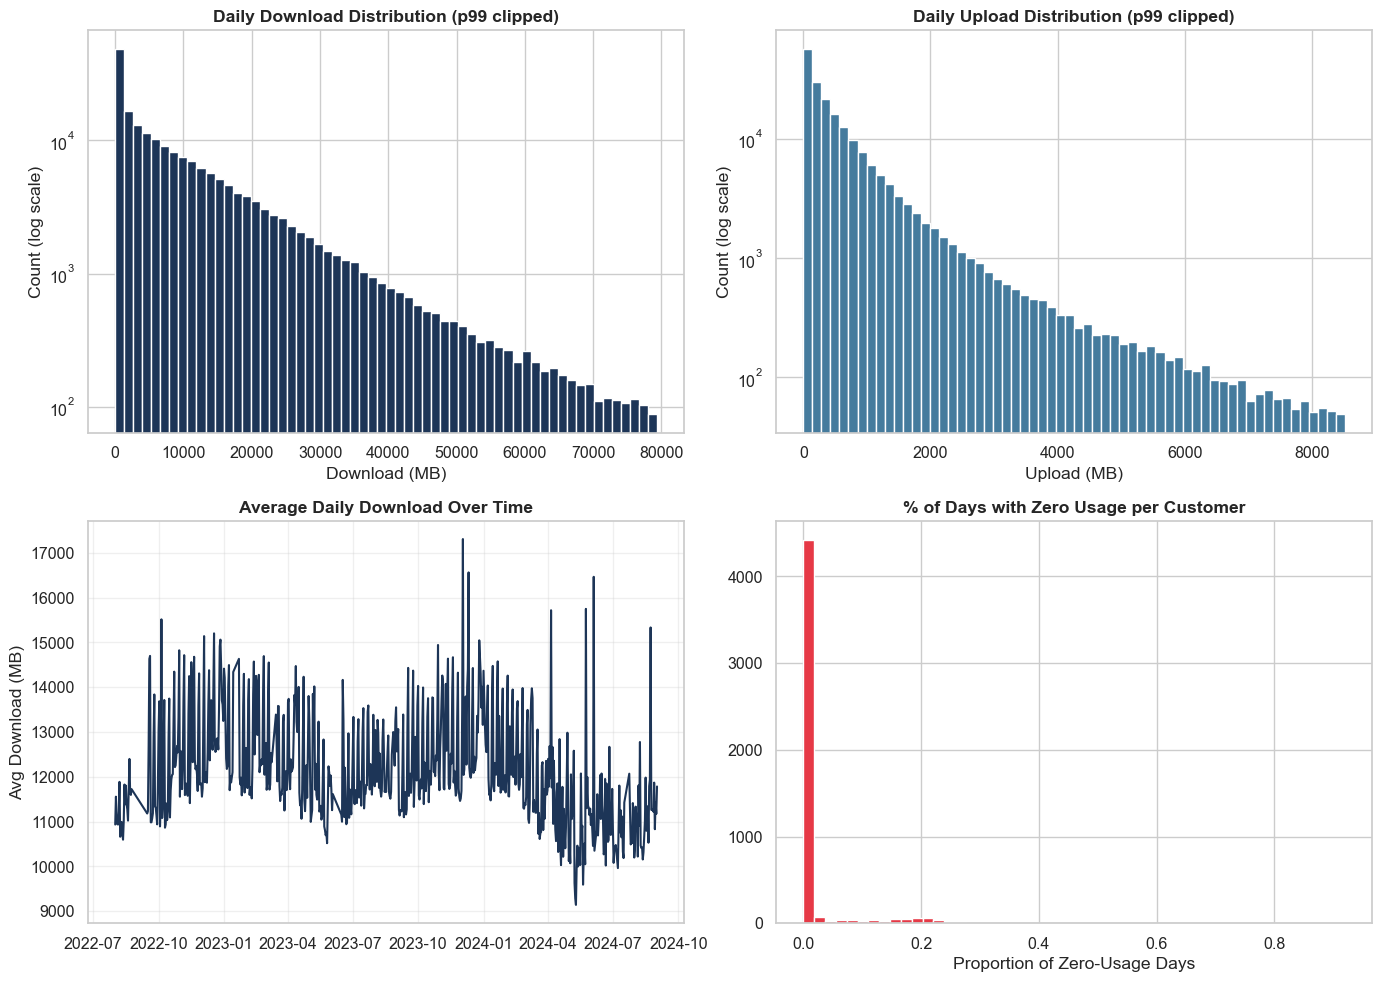

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Download distribution — clip at 99th percentile to suppress extreme outliers
dl_p99 = con.execute("""
    SELECT PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY TRY_CAST(usage_download_mbs AS DOUBLE))
    FROM usage WHERE TRY_CAST(usage_download_mbs AS DOUBLE) > 0
""").fetchone()[0]
dl_sample = con.execute(f"""
    SELECT TRY_CAST(usage_download_mbs AS DOUBLE) AS val
    FROM usage
    WHERE TRY_CAST(usage_download_mbs AS DOUBLE) BETWEEN 0 AND {dl_p99}
    USING SAMPLE 200000
""").fetchdf()
dl_sample['val'].hist(bins=60, ax=axes[0, 0], color=ACCENT, edgecolor='white', log=True)
axes[0, 0].set_title('Daily Download Distribution (p99 clipped)', fontweight='bold')
axes[0, 0].set_xlabel('Download (MB)')
axes[0, 0].set_ylabel('Count (log scale)')

# Upload distribution — clip at 99th percentile
ul_p99 = con.execute("""
    SELECT PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY TRY_CAST(usage_upload_mbs AS DOUBLE))
    FROM usage WHERE TRY_CAST(usage_upload_mbs AS DOUBLE) > 0
""").fetchone()[0]
ul_sample = con.execute(f"""
    SELECT TRY_CAST(usage_upload_mbs AS DOUBLE) AS val
    FROM usage
    WHERE TRY_CAST(usage_upload_mbs AS DOUBLE) BETWEEN 0 AND {ul_p99}
    USING SAMPLE 200000
""").fetchdf()
ul_sample['val'].hist(bins=60, ax=axes[0, 1], color=PALETTE['Active'], edgecolor='white', log=True)
axes[0, 1].set_title('Daily Upload Distribution (p99 clipped)', fontweight='bold')
axes[0, 1].set_xlabel('Upload (MB)')
axes[0, 1].set_ylabel('Count (log scale)')

# Daily mean download over time
daily = con.execute("""
    SELECT calendar_date,
           AVG(TRY_CAST(usage_download_mbs AS DOUBLE)) AS avg_dl
    FROM usage
    GROUP BY 1 ORDER BY 1
""").fetchdf()
axes[1, 0].plot(daily['calendar_date'], daily['avg_dl'], color=ACCENT, linewidth=1.5)
axes[1, 0].set_title('Average Daily Download Over Time', fontweight='bold')
axes[1, 0].set_ylabel('Avg Download (MB)')
axes[1, 0].grid(True, alpha=0.3)

# Zero-usage days per customer
zero = con.execute(f"""
    WITH per_cust AS (
        SELECT unique_customer_identifier,
               SUM(CASE WHEN TRY_CAST(usage_download_mbs AS DOUBLE) = 0
                        OR usage_download_mbs IS NULL THEN 1 ELSE 0 END) * 1.0
               / COUNT(*) AS zero_pct
        FROM usage
        GROUP BY 1
        HAVING COUNT(*) > 10
    )
    SELECT zero_pct FROM per_cust USING SAMPLE {VIZ_SAMPLE}
""").fetchdf()
zero['zero_pct'].hist(bins=50, ax=axes[1, 1], color=PALETTE['Churned'], edgecolor='white')
axes[1, 1].set_title('% of Days with Zero Usage per Customer', fontweight='bold')
axes[1, 1].set_xlabel('Proportion of Zero-Usage Days')

plt.tight_layout()
save_fig(fig, 'eda_usage_patterns')
plt.show()


> **Takeaway:** A significant population has high zero-usage days — likely inactive lines or pre-churn disengagement. Average daily downloads show seasonal variation worth controlling for.

---

## 5. Call Centre Behaviour

Call-centre interactions are a critical touchpoint. "Loyalty" calls specifically indicate the retention team has already flagged a customer as at-risk.

Call centre analysis uses a 50,000-row sample of 628,437 total call records.


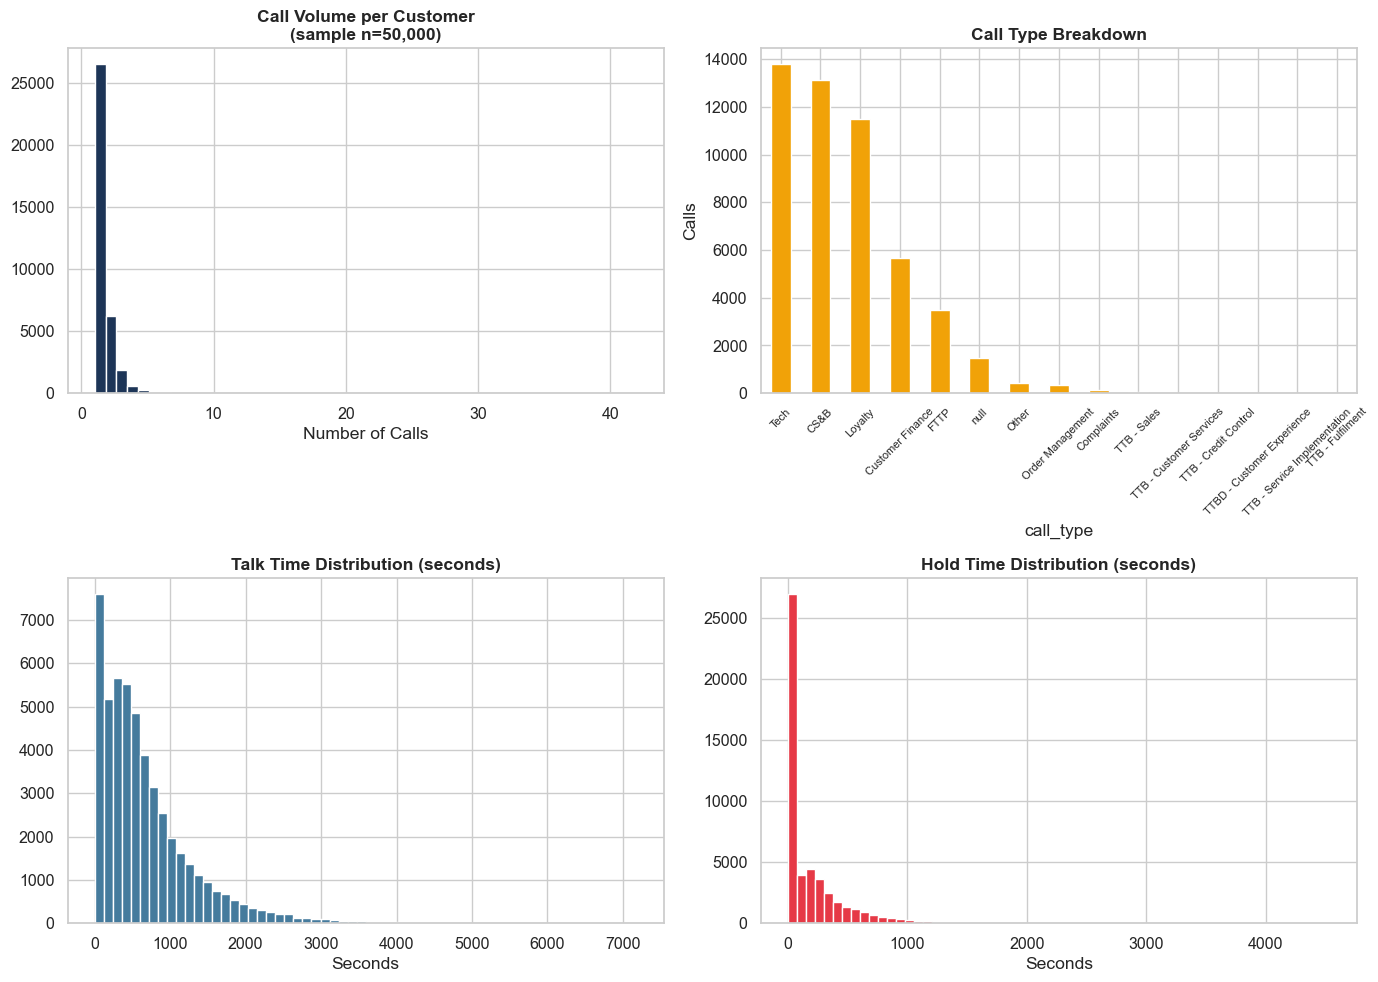

In [11]:

calls_sample = calls.sample(min(CALL_SAMPLE, len(calls)), random_state=42)
print(f'Call centre analysis uses a {len(calls_sample):,}-row sample of {len(calls):,} total call records.')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

calls_per = calls_sample.groupby('unique_customer_identifier').size()
calls_per.hist(bins=50, ax=axes[0, 0], color=ACCENT, edgecolor='white')
axes[0, 0].set_title(f'Call Volume per Customer\n(sample n={len(calls_sample):,})', fontweight='bold')
axes[0, 0].set_xlabel('Number of Calls')

calls_sample['call_type'].value_counts().plot(kind='bar', ax=axes[0, 1], color=WARN, edgecolor='white')
axes[0, 1].set_title('Call Type Breakdown', fontweight='bold')
axes[0, 1].set_ylabel('Calls')
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=8)

calls_sample['talk_time_seconds'].dropna().hist(bins=60, ax=axes[1, 0], color=PALETTE['Active'], edgecolor='white')
axes[1, 0].set_title('Talk Time Distribution (seconds)', fontweight='bold')
axes[1, 0].set_xlabel('Seconds')

calls_sample['hold_time_seconds'].dropna().hist(bins=60, ax=axes[1, 1], color=PALETTE['Churned'], edgecolor='white')
axes[1, 1].set_title('Hold Time Distribution (seconds)', fontweight='bold')
axes[1, 1].set_xlabel('Seconds')

plt.tight_layout()
save_fig(fig, 'eda_call_centre')
plt.show()


> **Takeaway:** Most customers have 1-3 calls. Loyalty calls are a distinct category — their presence is a strong churn signal (explored in depth in Section 8).

---

## 6. Bivariate Analysis — How Features Relate to Churn

We join the latest customer snapshot with churn labels to measure how each feature correlates with the decision to leave.

> **Methodological note:** The analytical base below is a *retrospective cross-section* — for churned customers, features are drawn from the last snapshot before their cease date (which varies from 2022 to 2024), while active customers are observed at the end of the window (Sep 2024). This means **time-varying features are not directly comparable** across the two groups. The downstream modelling notebooks use a properly temporalised panel design (same calendar-month snapshot for all customers) which avoids this issue.

Analytical base: 203,056 customers  |  Churned: 131,008  |  Active: 72,048  |  Churn rate in bivar: 64.5%


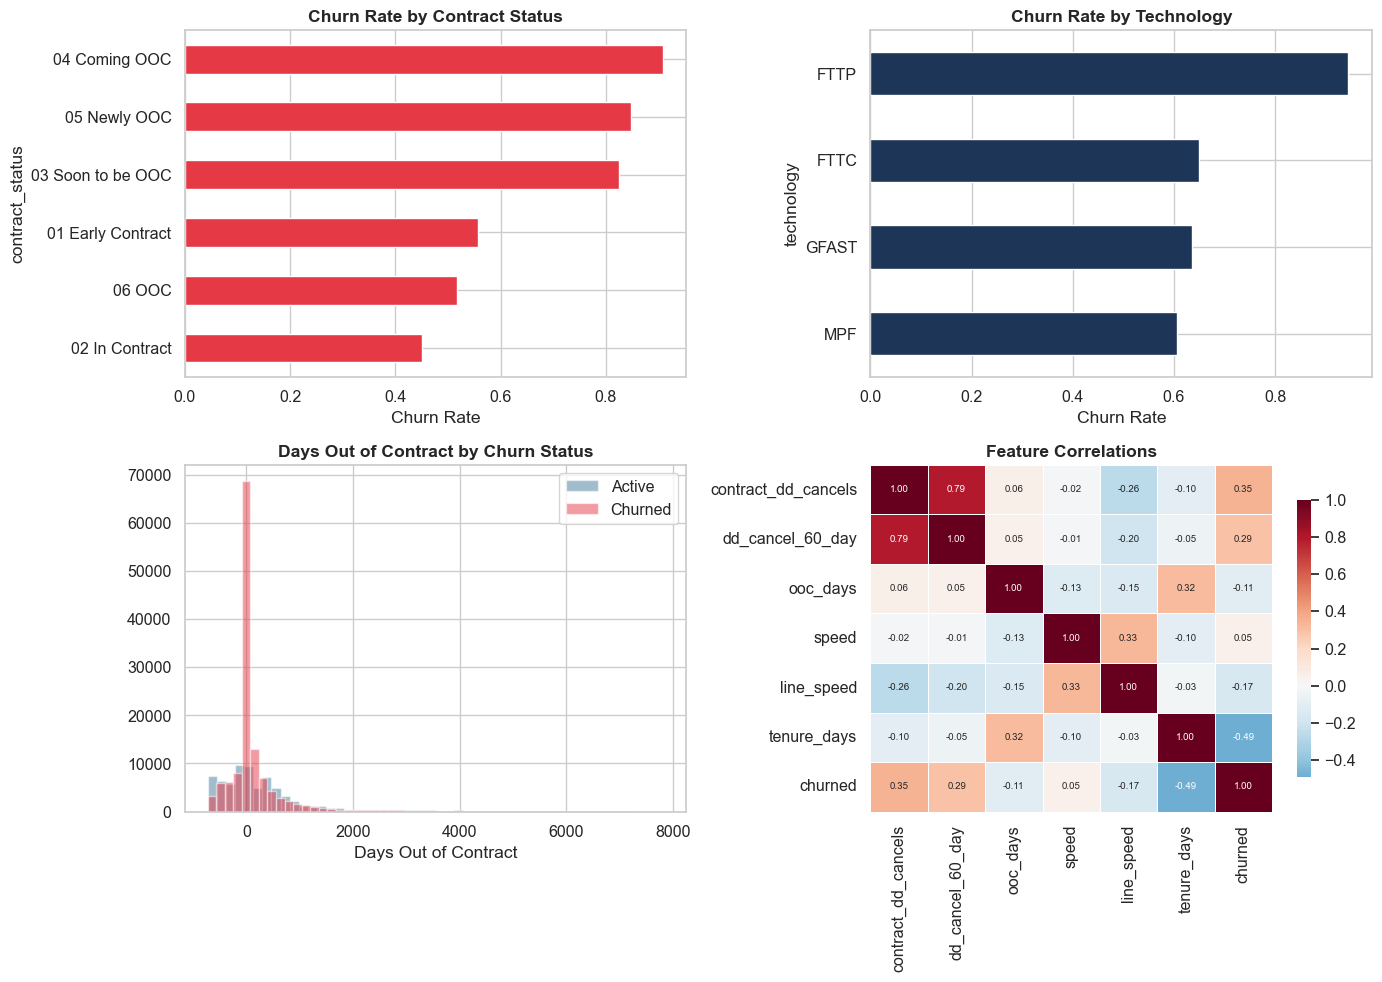

In [ ]:

# Build analytical base: latest PRE-CEASE customer snapshot + churn label
# IMPORTANT: For churned customers we take the snapshot ON OR BEFORE their
# first cease_placed_date to avoid data leakage (post-churn features).
# For active customers (no cease), we take the absolute latest snapshot.

bivar = con.execute("""
    WITH cease_dates AS (
        SELECT unique_customer_identifier,
               MIN(cease_placed_date::DATE) AS first_cease
        FROM cease
        GROUP BY 1
    ),
    anchor AS (
        SELECT ci.unique_customer_identifier,
               MAX(ci.datevalue) AS anchor_date
        FROM customer_info ci
        LEFT JOIN cease_dates cd USING (unique_customer_identifier)
        WHERE cd.first_cease IS NULL          -- active: no date bound
           OR ci.datevalue <= cd.first_cease   -- churned: pre-cease only
        GROUP BY 1
    )
    SELECT ci.*,
           CASE WHEN cd.first_cease IS NOT NULL THEN 1 ELSE 0 END AS churned
    FROM customer_info ci
    INNER JOIN anchor a USING (unique_customer_identifier)
    LEFT JOIN cease_dates cd USING (unique_customer_identifier)
    WHERE ci.datevalue = a.anchor_date
""").fetchdf()

# Guard: the date-join can produce duplicates when a customer has
# multiple rows on the same snapshot date — deduplicate to one per customer.
bivar = bivar.drop_duplicates('unique_customer_identifier', keep='first')

print(f'Analytical base: {len(bivar):,} customers  |  '
      f'Churned: {bivar["churned"].sum():,}  |  Active: {(bivar["churned"]==0).sum():,}  |  '
      f'Churn rate in bivar: {bivar["churned"].mean():.1%}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn rate by contract status
bivar.groupby('contract_status')['churned'].mean().sort_values().plot(
    kind='barh', ax=axes[0, 0], color=PALETTE['Churned'], edgecolor='white')
axes[0, 0].set_title('Churn Rate by Contract Status', fontweight='bold')
axes[0, 0].set_xlabel('Churn Rate')

# Churn rate by technology
bivar.groupby('technology')['churned'].mean().sort_values().plot(
    kind='barh', ax=axes[0, 1], color=ACCENT, edgecolor='white')
axes[0, 1].set_title('Churn Rate by Technology', fontweight='bold')
axes[0, 1].set_xlabel('Churn Rate')

# Out-of-contract days by churn status
for churn_val, grp in bivar.groupby('churned'):
    lbl = CHURN_LABEL_MAP[churn_val]
    grp['ooc_days'].dropna().hist(bins=50, alpha=0.5, ax=axes[1, 0],
                                   label=lbl, color=PALETTE[lbl])
axes[1, 0].legend()
axes[1, 0].set_title('Days Out of Contract by Churn Status', fontweight='bold')
axes[1, 0].set_xlabel('Days Out of Contract')

# Correlation heatmap (numeric features vs churn)
num_cols = bivar.select_dtypes(include='number').columns[:12]
corr = bivar[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1, 1], cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 7},
            linewidths=0.5)
axes[1, 1].set_title('Feature Correlations', fontweight='bold')

plt.tight_layout()
save_fig(fig, 'eda_bivariate')
plt.show()


> **Takeaway:** FTTP has the highest churn rate by technology (≈93 %). The correlation heatmap provides a first look at feature relationships.
>
> ⚠️ **FTTP churn caveat:** FTTP is the newest technology in the UK broadband market, so FTTP customers have inherently shorter tenure. Given the tenure measurement bias documented in §7 (churners' tenure frozen at exit vs actives accumulating to end of window), FTTP's elevated churn rate is at least partially a composition artefact — a higher proportion of FTTP customers fall into the short-tenure bands that mechanically inflate the retrospective churn rate. The interaction heatmap in §11 (Tenure × Technology) should be read with this in mind.
>
> ⚠️ **Technology has negligible overall association with churn:** The Cramér's V analysis in §11 shows Technology ↔ Churned = **0.041** (negligible), versus Contract Status ↔ Churned = **0.380** (moderate) and Sales Channel ↔ Churned = **0.366** (moderate). This means technology type explains almost none of the churn variation once you account for confounders. The high per-technology rates (FTTP ≈93 %) are driven by cohort composition (tenure, contract lifecycle), not by the technology itself.
>
> ⚠️ **Sales Channel is an overlooked predictor:** Sales Channel ↔ Churned V = **0.366** is the second strongest categorical association yet receives no dedicated bivariate analysis in this notebook. Different acquisition channels may attract customers with systematically different retention profiles (e.g. price-led online acquisitions vs. relationship-sold direct). Recommend adding a churn-by-channel breakdown and investigating whether channel proxies for customer quality or contract terms.
>
> ⚠️ **Simpson's paradox on contract status:** The raw churn-by-OOC chart may show in-contract customers churning at *higher* rates than out-of-contract. This is because in-contract customers who churn are captured at their pre-cease snapshot (when still in-contract), while long-tenured out-of-contract customers who remain active pull down the OOC churn rate. The bivariate view conflates cohort composition with contract-status effects — the survival model in later notebooks accounts for this correctly.

---

## 7. Tenure Analysis — Are Newer Customers More Vulnerable?

Customer tenure (time since activation) is often a top churn predictor. We explore whether newer customers are disproportionately at risk.

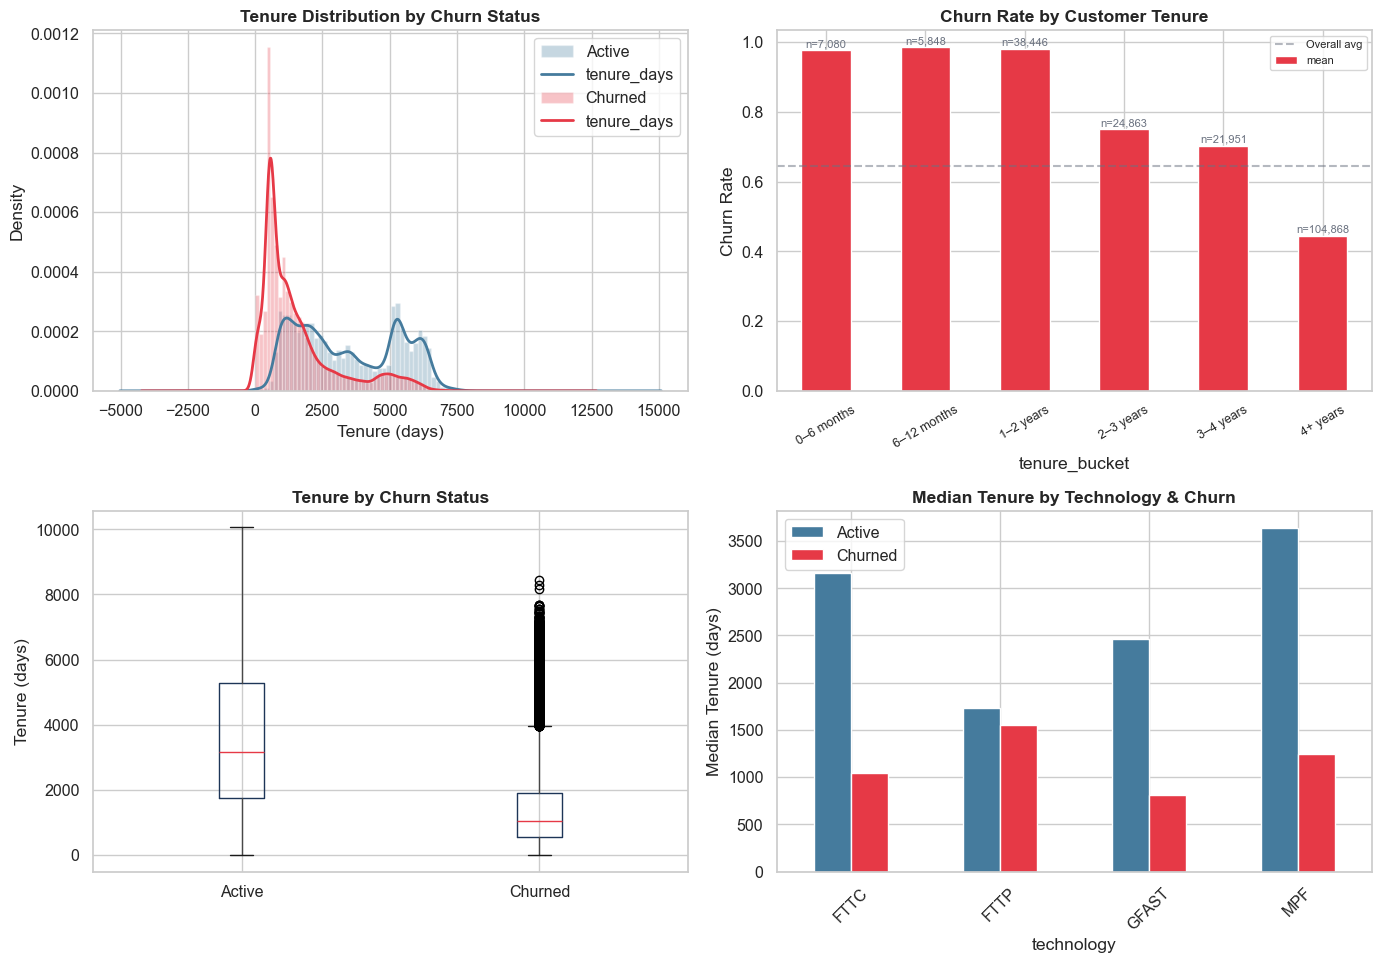

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tenure distribution by churn (overlaid KDE)
for churn_val, lbl in CHURN_LABEL_MAP.items():
    subset = bivar.loc[bivar['churned'] == churn_val, 'tenure_days'].dropna()
    subset.hist(bins=60, alpha=0.3, density=True, ax=axes[0, 0], color=PALETTE[lbl], label=lbl)
    subset.plot.kde(ax=axes[0, 0], color=PALETTE[lbl], linewidth=2)
axes[0, 0].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0, 0].set_xlabel('Tenure (days)')
axes[0, 0].legend()

# Churn rate by tenure bucket
bivar['tenure_bucket'] = pd.cut(
    bivar['tenure_days'],
    bins=[0, 180, 365, 730, 1095, 1460, bivar['tenure_days'].max() + 1],
    labels=['0–6 months', '6–12 months', '1–2 years', '2–3 years', '3–4 years', '4+ years']
)
tenure_churn = bivar.groupby('tenure_bucket', observed=True)['churned'].agg(['mean', 'count'])
tenure_churn['mean'].plot(kind='bar', ax=axes[0, 1], color=PALETTE['Churned'], edgecolor='white')
for i, (rate, cnt) in enumerate(zip(tenure_churn['mean'], tenure_churn['count'])):
    axes[0, 1].text(i, rate + 0.01, f'n={cnt:,}', ha='center', fontsize=8, color=NEUTRAL)
axes[0, 1].set_title('Churn Rate by Customer Tenure', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate')
axes[0, 1].tick_params(axis='x', rotation=30, labelsize=9)
axes[0, 1].axhline(bivar['churned'].mean(), color=NEUTRAL, linestyle='--', alpha=0.5, label='Overall avg')
axes[0, 1].legend(fontsize=8)

# Box-plot comparison
bivar.boxplot(column='tenure_days', by='churned', ax=axes[1, 0],
              boxprops=dict(color=ACCENT), medianprops=dict(color=PALETTE['Churned']))
axes[1, 0].set_title('Tenure by Churn Status', fontweight='bold')
axes[1, 0].set_xlabel('')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Active', 'Churned'])
axes[1, 0].set_ylabel('Tenure (days)')

# Median tenure by technology & churn
tenure_tech = bivar.groupby(['technology', 'churned'])['tenure_days'].median().unstack()
tenure_tech.columns = [CHURN_LABEL_MAP[c] for c in tenure_tech.columns]
tenure_tech.plot(kind='bar', ax=axes[1, 1],
                 color=[PALETTE['Active'], PALETTE['Churned']], edgecolor='white')
axes[1, 1].set_title('Median Tenure by Technology & Churn', fontweight='bold')
axes[1, 1].set_ylabel('Median Tenure (days)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
save_fig(fig, 'eda_tenure')
plt.show()


> **Takeaway:** Tenure is the strongest single numerical correlate of churn (r = −0.49). Customers with tenure under 2 years at their measurement point have near-universal churn rates (≈98 %). Across all technologies, churned customers have substantially shorter tenure.
>
> ⚠️ **Critical caveat — survivorship / measurement bias:**
> - In this retrospective analytical base, **churned customers have their tenure frozen at the time of churn**, while **active customers accumulate tenure until the end of the observation window** (Sep 2024).
> - This mechanically inflates the tenure–churn correlation: a customer who left after 6 months has tenure = 180 days, while one who stays 4 years has tenure = 1,460 days — *by construction*, not because short tenure *causes* churn.
> - The "≈98 % churn under 2 years" figure reflects this: only **1.4 %** of active customers have tenure < 2 years (they've had time to accumulate), while **38.4 %** of churners were measured at < 2 years. The rate is a compositional artefact, not an at-risk probability.
> - **Implication for modelling:** Tenure remains a valid predictor in a point-in-time model (where all customers are measured at the same calendar date), but the r = −0.49 correlation is an *upper bound* — the true effect in a properly temporalised model is weaker. The survival model (notebook 07) handles this correctly with time-at-risk accounting.
>
> ⚠️ **KDE visualisation note:** The tenure distribution plot shows density extending below zero — this is a **kernel smoothing artefact**, not actual negative tenure values. The data quality checks (notebook 02) confirm **0 rows** have `tenure_days < 0`. The Gaussian KDE kernel bleeds density below the natural boundary at zero because many churned customers have short tenure values close to the lower bound. This is a well-known limitation of unbounded KDE estimation on non-negative data.

---

## 8. Call Pattern Deep-Dive — The Loyalty Call Signal

Do customers who contact the call centre more frequently churn at higher rates? More importantly, is a "Loyalty" call — where the retention team intervenes — a strong leading indicator?

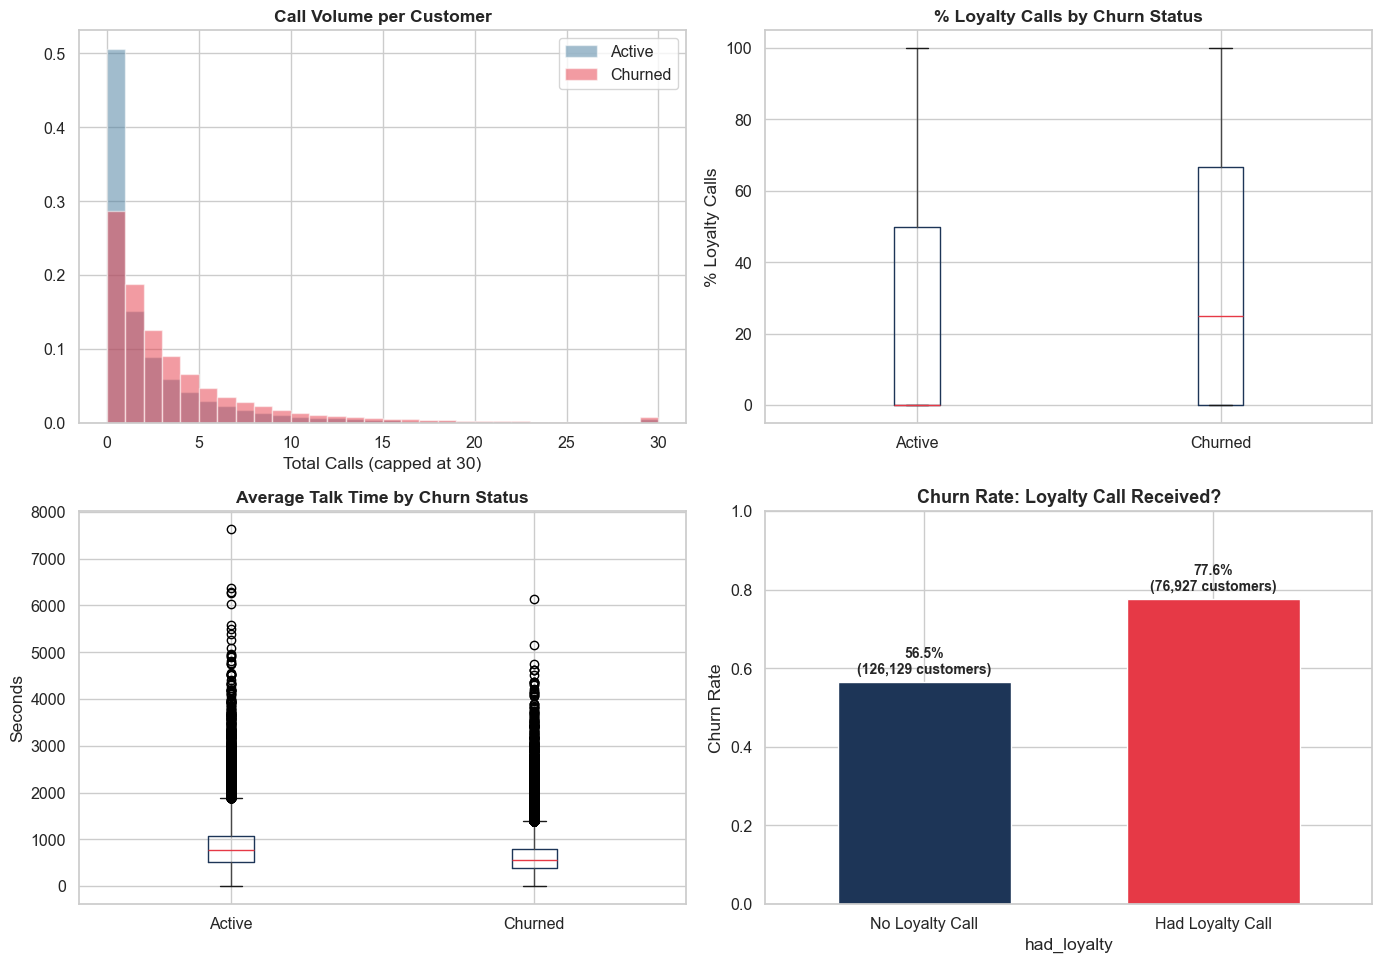

In [14]:

# Aggregate call features per customer from full calls table (628K records via DuckDB)
call_agg = con.execute("""
    SELECT
        c.unique_customer_identifier,
        COUNT(*)                                         AS total_calls,
        count_if(c.call_type = 'Loyalty')                AS loyalty_calls,
        count_if(c.call_type = 'Loyalty') * 100.0
            / NULLIF(COUNT(*), 0)                        AS pct_loyalty,
        AVG(c.talk_time_seconds)                         AS avg_talk_time,
        AVG(c.hold_time_seconds)                         AS avg_hold_time,
        MAX(c.talk_time_seconds)                         AS max_talk_time
    FROM calls c
    GROUP BY 1
""").fetchdf()

bivar_calls = bivar.merge(call_agg, on='unique_customer_identifier', how='left')
bivar_calls['total_calls']   = bivar_calls['total_calls'].fillna(0)
bivar_calls['loyalty_calls'] = bivar_calls['loyalty_calls'].fillna(0)
bivar_calls['has_calls']     = (bivar_calls['total_calls'] > 0).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Call volume by churn
for lbl in CHURN_LABEL_MAP.values():
    churn_val = CHURN_VAL_MAP[lbl]
    bivar_calls.loc[bivar_calls['churned'] == churn_val, 'total_calls'].clip(upper=30).hist(
        bins=30, alpha=0.5, density=True, ax=axes[0, 0], color=PALETTE[lbl], label=lbl)
axes[0, 0].set_title('Call Volume per Customer', fontweight='bold')
axes[0, 0].set_xlabel('Total Calls (capped at 30)')
axes[0, 0].legend()

# Loyalty call % by churn
bivar_calls[bivar_calls['has_calls'] == 1].boxplot(
    column='pct_loyalty', by='churned', ax=axes[0, 1],
    boxprops=dict(color=ACCENT), medianprops=dict(color=PALETTE['Churned']))
axes[0, 1].set_title('% Loyalty Calls by Churn Status', fontweight='bold')
axes[0, 1].set_xlabel('')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Active', 'Churned'])
axes[0, 1].set_ylabel('% Loyalty Calls')

# Avg talk time by churn
bivar_calls[bivar_calls['has_calls'] == 1].boxplot(
    column='avg_talk_time', by='churned', ax=axes[1, 0],
    boxprops=dict(color=ACCENT), medianprops=dict(color=PALETTE['Churned']))
axes[1, 0].set_title('Average Talk Time by Churn Status', fontweight='bold')
axes[1, 0].set_xlabel('')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Active', 'Churned'])
axes[1, 0].set_ylabel('Seconds')

# KEY INSIGHT: Had loyalty call vs not
bivar_calls['had_loyalty'] = (bivar_calls['loyalty_calls'] > 0).astype(int)
loyalty_churn = bivar_calls.groupby('had_loyalty')['churned'].agg(['mean', 'count'])
loyalty_churn['mean'].plot(kind='bar', ax=axes[1, 1],
    color=[ACCENT, PALETTE['Churned']], edgecolor='white', width=0.6)
for i, (rate, cnt) in enumerate(zip(loyalty_churn['mean'], loyalty_churn['count'])):
    axes[1, 1].text(i, rate + 0.02, f'{rate:.1%}\n({cnt:,} customers)',
                     ha='center', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Churn Rate: Loyalty Call Received?', fontweight='bold', fontsize=13)
axes[1, 1].set_xticklabels(['No Loyalty Call', 'Had Loyalty Call'], rotation=0)
axes[1, 1].set_ylabel('Churn Rate')
axes[1, 1].set_ylim(0, 1)

plt.suptitle('')
plt.tight_layout()
save_fig(fig, 'eda_call_patterns')
plt.show()


> **Observation:** Customers who received a Loyalty call churn at **77.6 %** vs **56.5 %** for those who didn't.
>
> ⚠️ **Reverse causality — this is NOT a causal finding:**
> - **41 % of all loyalty calls occur on or after the cease-placed date.** Loyalty calls are a *consequence* of churn intent, not a leading indicator — the retention team contacts customers *because* they have already signalled they want to leave.
> - The 77.6 % rate reflects selection bias: loyally-called customers are pre-selected as high-risk by the existing retention process.
> - **Correct interpretation:** The retention team is already reaching at-risk customers, but often too late. A predictive model should trigger intervention *before* the customer reaches the loyalty-call stage. In downstream modelling (notebook 07), loyalty call features are treated as **treatment variables** with explicit reverse-causality caveats, not as conventional predictors.

---

## 9. Cease Timing & Seasonality

Understanding *when* churn happens guides operational planning and model temporal design.

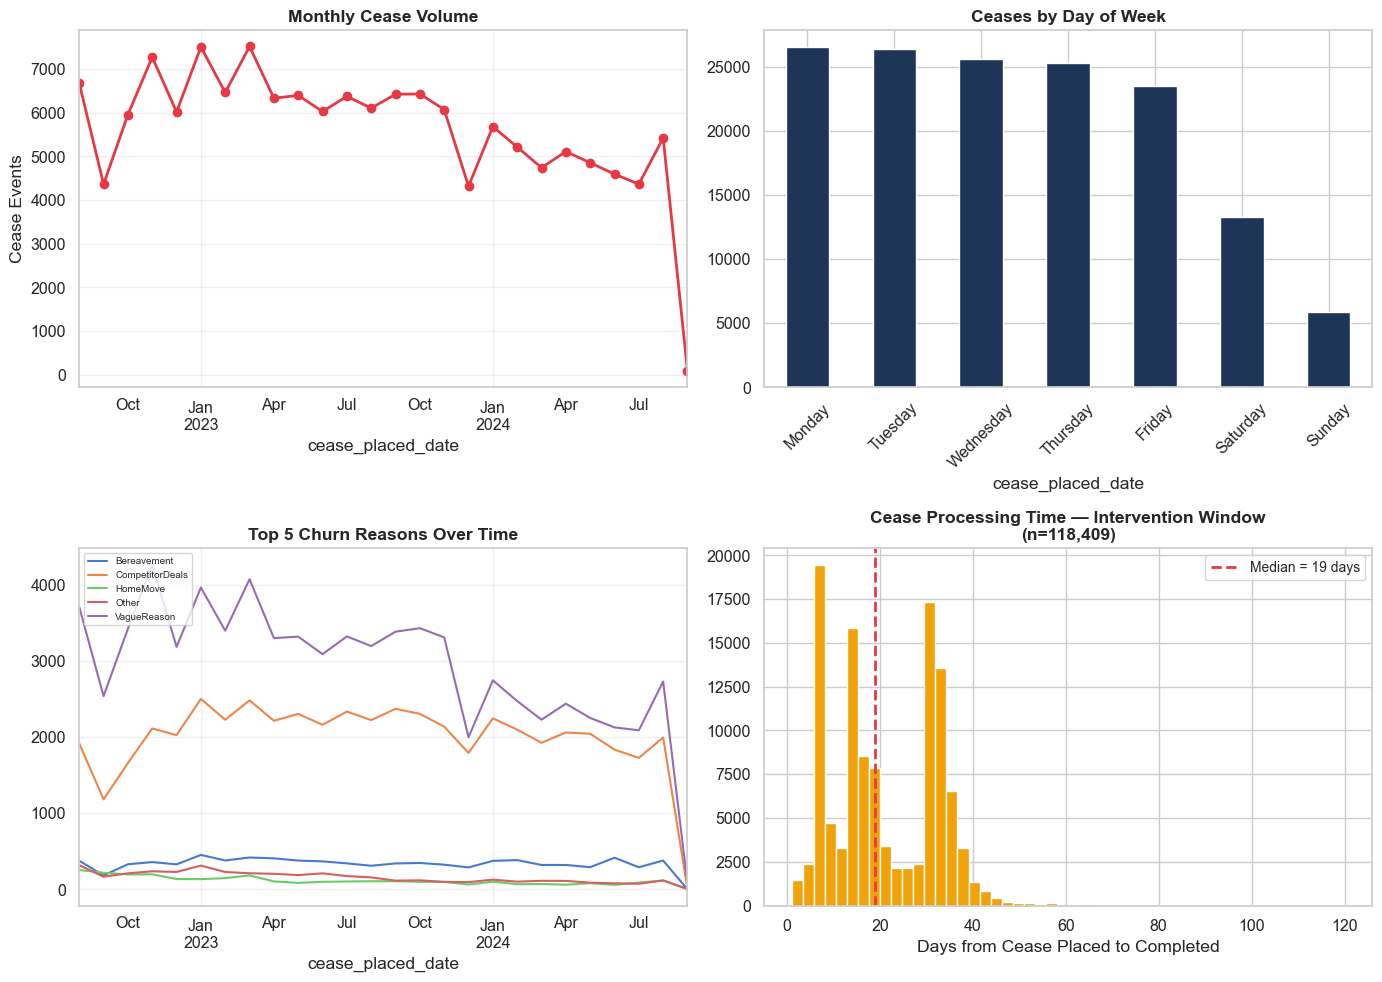

In [15]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cease_dt = cease.copy()
cease_dt['cease_placed_date']    = pd.to_datetime(cease_dt['cease_placed_date'],    errors='coerce')
cease_dt['cease_completed_date'] = pd.to_datetime(cease_dt['cease_completed_date'], errors='coerce')

# Monthly cease volume
monthly_churn = cease_dt.set_index('cease_placed_date').resample('ME').size()
monthly_churn.plot(ax=axes[0, 0], marker='o', color=PALETTE['Churned'], linewidth=2)
axes[0, 0].set_title('Monthly Cease Volume', fontweight='bold')
axes[0, 0].set_ylabel('Cease Events')
axes[0, 0].grid(True, alpha=0.3)

# Day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = cease_dt['cease_placed_date'].dt.day_name().value_counts().reindex(dow_order)
dow_counts.plot(kind='bar', ax=axes[0, 1], color=ACCENT, edgecolor='white')
axes[0, 1].set_title('Ceases by Day of Week', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Top 5 churn reasons over time
top_reasons = cease_dt['reason_description_insight'].value_counts().head(5).index
cease_reason_monthly = (
    cease_dt[cease_dt['reason_description_insight'].isin(top_reasons)]
    .groupby([pd.Grouper(key='cease_placed_date', freq='ME'), 'reason_description_insight'])
    .size().unstack(fill_value=0)
)
cease_reason_monthly.plot(ax=axes[1, 0], linewidth=1.5)
axes[1, 0].set_title('Top 5 Churn Reasons Over Time', fontweight='bold')
axes[1, 0].legend(fontsize=7, loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# Cease processing time (intervention window)
cease_dt['days_to_complete'] = (cease_dt['cease_completed_date'] - cease_dt['cease_placed_date']).dt.days
valid_ttc = cease_dt['days_to_complete'].dropna()
valid_ttc = valid_ttc[(valid_ttc >= 0) & (valid_ttc <= 120)]
valid_ttc.hist(bins=50, ax=axes[1, 1], color=WARN, edgecolor='white')
axes[1, 1].set_title(f'Cease Processing Time — Intervention Window\n(n={len(valid_ttc):,})',
                      fontweight='bold')
axes[1, 1].set_xlabel('Days from Cease Placed to Completed')
axes[1, 1].axvline(valid_ttc.median(), color=PALETTE['Churned'], linestyle='--', linewidth=2,
                    label=f'Median = {valid_ttc.median():.0f} days')
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
save_fig(fig, 'eda_cease_timing')
plt.show()


> **Takeaway:** Ceases peak mid-week and show a declining trend through 2024. The median 19-day processing window represents an opportunity for save-desk intervention before the cease completes.

---

## 10. Speed Gap Analysis — Are Customers Getting What They Pay For?

The "speed gap" (provisioned speed minus actual line speed) measures whether customers receive the broadband performance they expect. Persistent underperformance may drive dissatisfaction and churn.

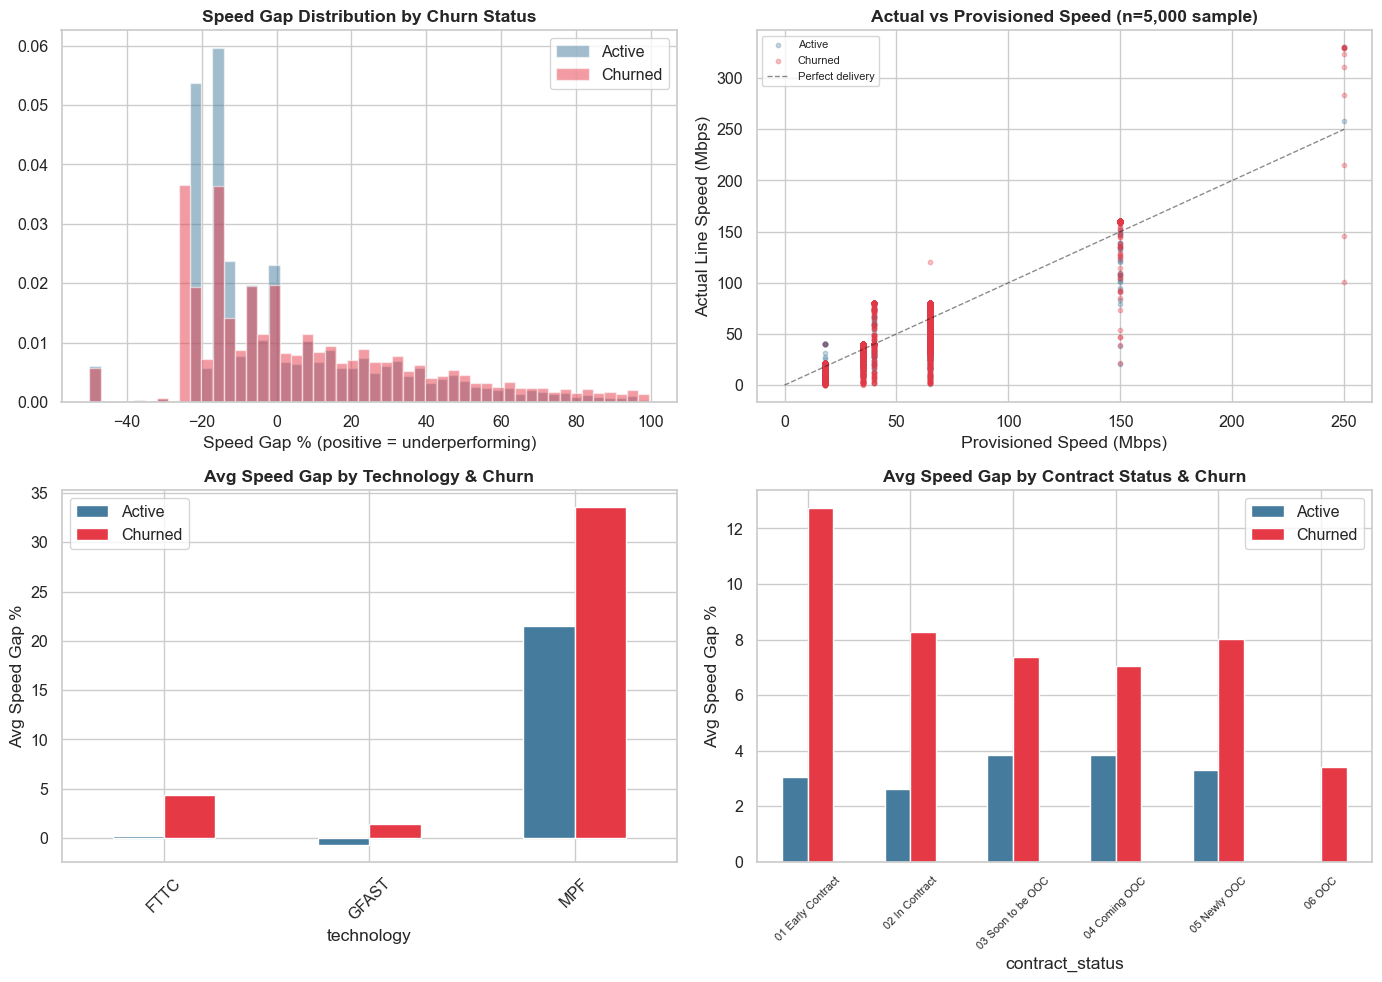

Speed gap comparison (n=147,783 customers with measured line speed):


,Mean Speed Gap %,Median Speed Gap %
Active,1.600000,-6.600000
Churned,6.900000,0.000000


In [16]:

# Speed gap = (provisioned - actual) / provisioned × 100
spd_df = bivar[bivar['line_speed'].notna() & (bivar['line_speed'] > 0)].copy()
spd_df['speed_gap']     = spd_df['speed'] - spd_df['line_speed']
spd_df['speed_gap_pct'] = (spd_df['speed_gap'] / spd_df['speed']) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Speed gap distribution by churn
for lbl in CHURN_LABEL_MAP.values():
    churn_val = CHURN_VAL_MAP[lbl]
    subset = spd_df.loc[spd_df['churned'] == churn_val, 'speed_gap_pct'].clip(-50, 100)
    subset.hist(bins=50, alpha=0.5, density=True, ax=axes[0, 0], color=PALETTE[lbl], label=lbl)
axes[0, 0].set_title('Speed Gap Distribution by Churn Status', fontweight='bold')
axes[0, 0].set_xlabel('Speed Gap % (positive = underperforming)')
axes[0, 0].legend()

# Scatter: actual vs provisioned speed (VIZ_SAMPLE points)
sample_spd = spd_df.sample(min(VIZ_SAMPLE, len(spd_df)), random_state=42)
for lbl in CHURN_LABEL_MAP.values():
    churn_val = CHURN_VAL_MAP[lbl]
    mask = sample_spd['churned'] == churn_val
    axes[0, 1].scatter(sample_spd.loc[mask, 'speed'],
                        sample_spd.loc[mask, 'line_speed'],
                        alpha=0.3, s=10, color=PALETTE[lbl], label=lbl)
axes[0, 1].plot([0, spd_df['speed'].max()], [0, spd_df['speed'].max()],
                'k--', linewidth=1, alpha=0.5, label='Perfect delivery')
axes[0, 1].set_title(f'Actual vs Provisioned Speed (n={len(sample_spd):,} sample)', fontweight='bold')
axes[0, 1].set_xlabel('Provisioned Speed (Mbps)')
axes[0, 1].set_ylabel('Actual Line Speed (Mbps)')
axes[0, 1].legend(fontsize=8)

# Speed gap by technology & churn
gap_tech = spd_df.groupby(['technology', 'churned'])['speed_gap_pct'].mean().unstack()
gap_tech.columns = [CHURN_LABEL_MAP[c] for c in gap_tech.columns]
gap_tech.plot(kind='bar', ax=axes[1, 0],
              color=[PALETTE['Active'], PALETTE['Churned']], edgecolor='white')
axes[1, 0].set_title('Avg Speed Gap by Technology & Churn', fontweight='bold')
axes[1, 0].set_ylabel('Avg Speed Gap %')
axes[1, 0].tick_params(axis='x', rotation=45)

# Speed gap by contract status & churn
gap_status = spd_df.groupby(['contract_status', 'churned'])['speed_gap_pct'].mean().unstack()
gap_status.columns = [CHURN_LABEL_MAP[c] for c in gap_status.columns]
gap_status.plot(kind='bar', ax=axes[1, 1],
                color=[PALETTE['Active'], PALETTE['Churned']], edgecolor='white')
axes[1, 1].set_title('Avg Speed Gap by Contract Status & Churn', fontweight='bold')
axes[1, 1].set_ylabel('Avg Speed Gap %')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
save_fig(fig, 'eda_speed_gap')
plt.show()

# Executive-friendly summary
gap_summary = spd_df.groupby('churned')['speed_gap_pct'].agg(['mean', 'median']).round(1)
gap_summary.index = [CHURN_LABEL_MAP[i] for i in gap_summary.index]
gap_summary.columns = ['Mean Speed Gap %', 'Median Speed Gap %']
print(f'Speed gap comparison (n={len(spd_df):,} customers with measured line speed):')
display(gap_summary.style.set_caption('Speed Gap: Active vs Churned Customers'))


> **Takeaway:** Churned customers experience a mean speed gap of **6.9 %** vs **1.6 %** for active customers. MPF technology shows the largest gap (≈34 % for churned).
>
> ⚠️ **Mean vs median divergence:** The **median** speed gap is **0.0 %** for churned and **−6.6 %** for active (i.e. active customers are *over-delivered* on average). The mean is pulled upward by a tail of severe underperformers. Both statistics should be considered: the mean captures the impact of outlier underperformance, but the median shows that the *typical* churner is not speed-disadvantaged. Targeted remediation should focus on the underperforming tail, not the broad customer population.

---

## 11. Multivariate Analysis — How Features Interact

Individual features don't act in isolation. This section examines how combinations of contract status, tenure, technology, and financial signals compound churn risk.

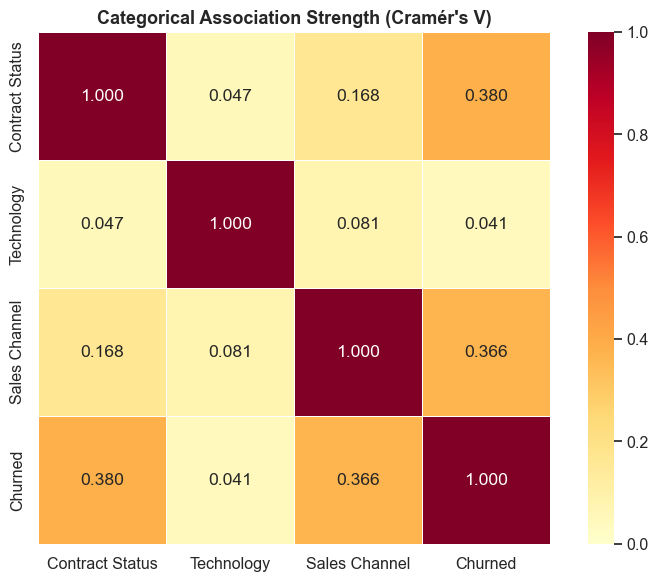

Interpretation: ≥ 0.1 weak | ≥ 0.3 moderate | ≥ 0.5 strong association


In [17]:

# ── Categorical association strength (Cramér's V) ──
# cramers_v() is defined in the helper functions cell at the top of this notebook.

cat_cols = ['contract_status', 'technology', 'sales_channel', 'churned']
cat_pairs = list(itertools.combinations(cat_cols, 2))
cv_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols, columns=cat_cols
)
for col_a, col_b in cat_pairs:
    v = cramers_v(bivar[col_a].astype(str), bivar[col_b].astype(str))
    cv_matrix.loc[col_a, col_b] = v
    cv_matrix.loc[col_b, col_a] = v
np.fill_diagonal(cv_matrix.values, 1.0)

# Readable display names
display_names = {
    'contract_status': 'Contract Status',
    'technology':      'Technology',
    'sales_channel':   'Sales Channel',
    'churned':         'Churned',
}
cv_display = cv_matrix.rename(index=display_names, columns=display_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cv_display.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Categorical Association Strength (Cramér's V)", fontweight='bold', fontsize=13)
plt.tight_layout()
save_fig(fig, 'eda_cramers_v')
plt.show()
print("Interpretation: ≥ 0.1 weak | ≥ 0.3 moderate | ≥ 0.5 strong association")


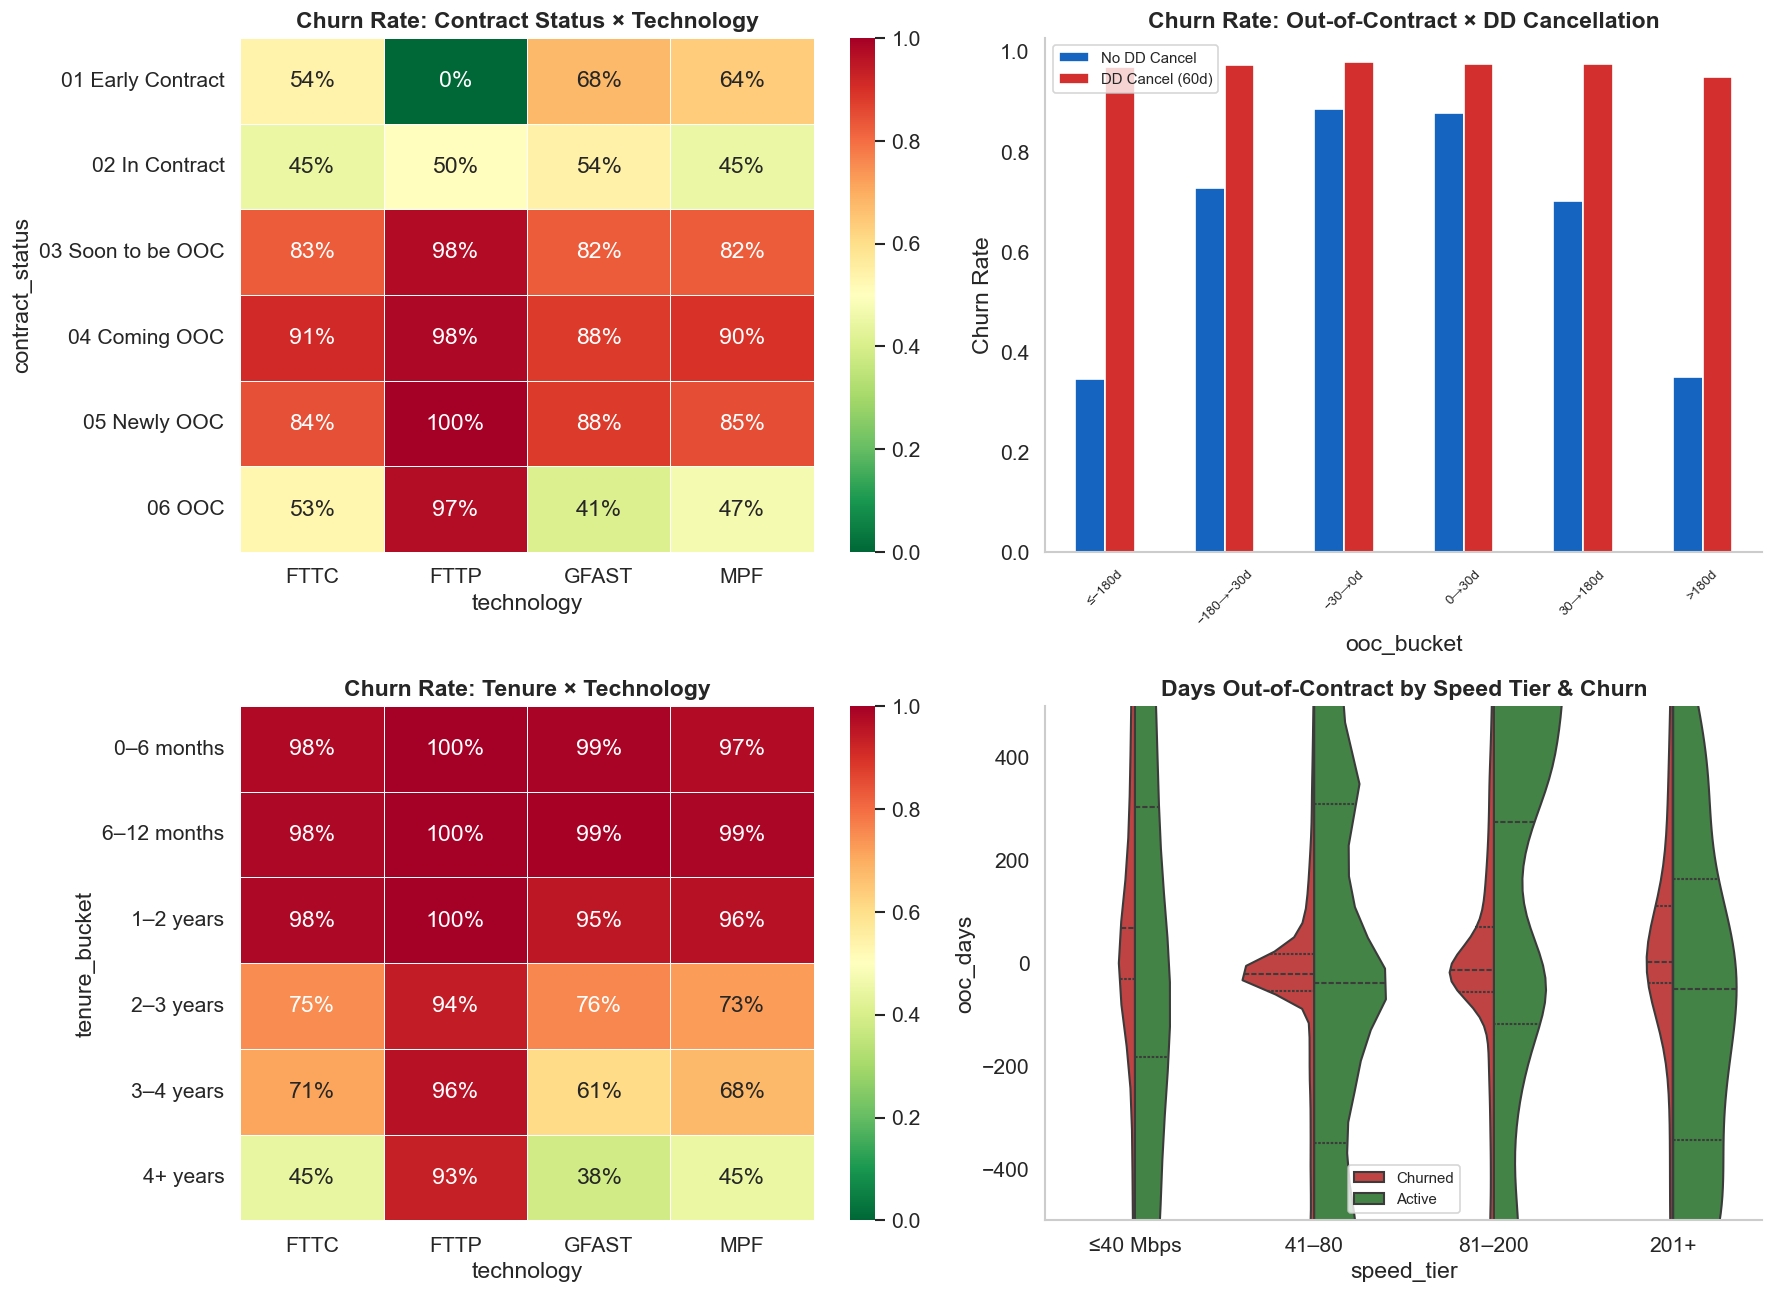

In [ ]:

# ── Interaction effects: how feature combinations compound churn risk ──
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Contract Status × Technology → Churn rate
ct_churn = bivar.groupby(['contract_status', 'technology'])['churned'].mean().unstack()
sns.heatmap(ct_churn, annot=True, fmt='.0%', cmap='RdYlGn_r', ax=axes[0, 0],
            linewidths=0.5, vmin=0, vmax=1)
axes[0, 0].set_title('Churn Rate: Contract Status × Technology', fontweight='bold')

# OOC bucket × DD cancel → Churn rate
bivar['ooc_bucket'] = pd.cut(
    bivar['ooc_days'].fillna(0),
    bins=[-9999, -180, -30, 0, 30, 180, 9999],
    labels=['≤−180d', '−180→−30d', '−30→0d', '0→30d', '30→180d', '>180d']
)
ooc_dd = (bivar
    .groupby(['ooc_bucket', 'dd_cancel_60_day'], observed=True)['churned']
    .agg(['mean', 'count'])
    .reset_index())
ooc_dd_pivot = ooc_dd.pivot(index='ooc_bucket', columns='dd_cancel_60_day', values='mean')
ooc_dd_pivot.columns = ['No DD Cancel', 'DD Cancel (60d)']
ooc_dd_pivot.plot(kind='bar', ax=axes[0, 1], color=[ACCENT, PALETTE['Churned']], edgecolor='white')
axes[0, 1].set_title('Churn Rate: Out-of-Contract × DD Cancellation', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate')
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=8)
axes[0, 1].legend(fontsize=9)

# Tenure × Technology → Churn rate
tenure_tech_churn = bivar.groupby(['tenure_bucket', 'technology'], observed=True)['churned'].mean().unstack()
sns.heatmap(tenure_tech_churn, annot=True, fmt='.0%', cmap='RdYlGn_r', ax=axes[1, 0],
            linewidths=0.5, vmin=0, vmax=1)
axes[1, 0].set_title('Churn Rate: Tenure × Technology', fontweight='bold')

# Speed tier × Churn → OOC days violin
bivar['speed_tier'] = pd.cut(bivar['speed'], bins=[0, 40, 80, 200, 1000],
                              labels=['≤40 Mbps', '41–80', '81–200', '201+'])
violin_data = bivar[bivar['ooc_days'].notna()].copy()
violin_data['churn_label'] = violin_data['churned'].map(CHURN_LABEL_MAP)
sns.violinplot(data=violin_data, x='speed_tier', y='ooc_days', hue='churn_label',
               split=True, ax=axes[1, 1], palette=PALETTE,
               inner='quartile', cut=0)
axes[1, 1].set_title('Days Out-of-Contract by Speed Tier & Churn', fontweight='bold')
axes[1, 1].set_ylim(-500, 500)
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
save_fig(fig, 'eda_interactions')
plt.show()


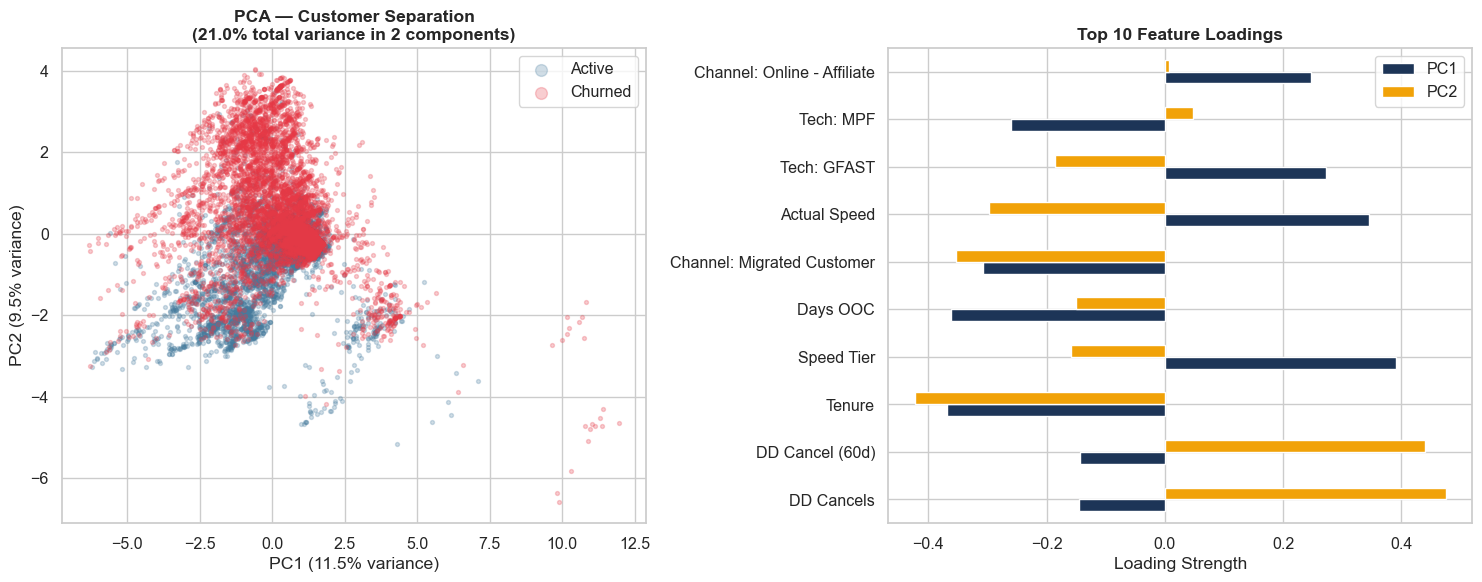

Note: 22 features used (one-hot for nominal categoricals; ordinal for contract status).


In [18]:

# ── Dimensionality reduction: Can we visually separate churned customers? ──
# NOTE: contract_status is genuinely ordinal ('01 Early Contract' → '06 OOC'),
#       so ordinal encoding is correct for it.
#       technology and sales_channel are NOMINAL — we one-hot encode these
#       to avoid imposing fake ordinal distances in PCA space.
# Imports (StandardScaler, OrdinalEncoder, PCA) are loaded in the top imports cell.

pca_df = bivar.copy()

# Ordinal: contract_status (already prefixed with sort-order numbers)
pca_df['contract_status_ord'] = OrdinalEncoder(
    categories=[sorted(pca_df['contract_status'].dropna().unique())]
).fit_transform(pca_df[['contract_status']].fillna('Unknown'))

# Nominal: one-hot encode technology and sales_channel
tech_dummies    = pd.get_dummies(pca_df['technology'].fillna('Unknown'),    prefix='tech',  drop_first=True)
channel_dummies = pd.get_dummies(pca_df['sales_channel'].fillna('Unknown'), prefix='chan',  drop_first=True)
pca_df = pd.concat([pca_df, tech_dummies, channel_dummies], axis=1)

feature_cols = (['tenure_days', 'ooc_days', 'speed', 'line_speed',
                 'contract_dd_cancels', 'dd_cancel_60_day', 'contract_status_ord']
                + list(tech_dummies.columns) + list(channel_dummies.columns))
X_pca   = pca_df[feature_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X_pca)

pca   = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA scatter — VIZ_SAMPLE points for readability
rng          = np.random.RandomState(42)
idx_sample   = rng.choice(len(coords), min(VIZ_SAMPLE * 2, len(coords)), replace=False)
for lbl in CHURN_LABEL_MAP.values():
    churn_val = CHURN_VAL_MAP[lbl]
    mask = pca_df.iloc[idx_sample]['churned'].values == churn_val
    axes[0].scatter(coords[idx_sample[mask], 0], coords[idx_sample[mask], 1],
                    alpha=0.25, s=8, color=PALETTE[lbl], label=lbl)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title(
    f'PCA — Customer Separation\n({sum(pca.explained_variance_ratio_):.1%} total variance in 2 components)',
    fontweight='bold')
axes[0].legend(markerscale=3)

# Feature loadings — top 10 by absolute loading on PC1/PC2
readable_names = {
    'tenure_days':           'Tenure',
    'ooc_days':              'Days OOC',
    'speed':                 'Speed Tier',
    'line_speed':            'Actual Speed',
    'contract_dd_cancels':   'DD Cancels',
    'dd_cancel_60_day':      'DD Cancel (60d)',
    'contract_status_ord':   'Contract Status (ordinal)',
}
all_names = {
    c: readable_names.get(c, c.replace('tech_', 'Tech: ').replace('chan_', 'Channel: '))
    for c in feature_cols
}
loadings  = pd.DataFrame(pca.components_.T,
                          index=[all_names[c] for c in feature_cols],
                          columns=['PC1', 'PC2'])
top_idx   = loadings.abs().max(axis=1).nlargest(10).index
loadings.loc[top_idx].plot(kind='barh', ax=axes[1], color=[ACCENT, WARN], edgecolor='white')
axes[1].set_title('Top 10 Feature Loadings', fontweight='bold')
axes[1].set_xlabel('Loading Strength')

plt.tight_layout()
save_fig(fig, 'eda_pca')
plt.show()
print(f'Note: {len(feature_cols)} features used (one-hot for nominal categoricals; ordinal for contract status).')


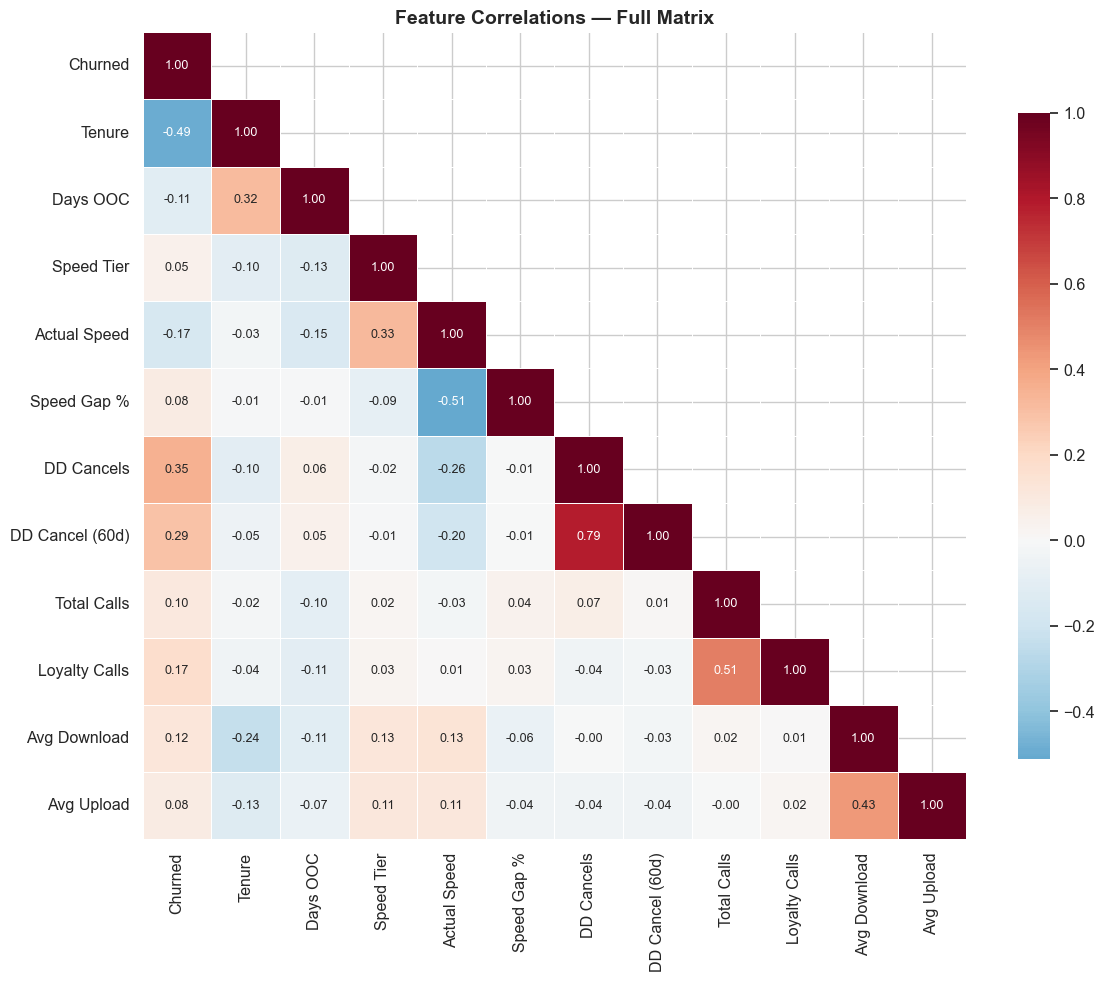

,Feature,|Correlation with Churn|,Direction
Rank,,,
1,Tenure,0.490,⬇ Higher → Less Churn
2,DD Cancels,0.353,⬆ Higher → More Churn
3,DD Cancel (60d),0.292,⬆ Higher → More Churn
4,Loyalty Calls,0.175,⬆ Higher → More Churn
5,Actual Speed,0.168,⬇ Higher → Less Churn
6,Avg Download,0.124,⬆ Higher → More Churn
7,Days OOC,0.112,⬇ Higher → Less Churn
8,Total Calls,0.103,⬆ Higher → More Churn
9,Avg Upload,0.083,⬆ Higher → More Churn


In [19]:

# ── Comprehensive correlation matrix: all key features vs churn ──
usage_agg = con.execute("""
    SELECT
        unique_customer_identifier,
        AVG(TRY_CAST(usage_download_mbs AS DOUBLE))  AS avg_download_mbs,
        AVG(TRY_CAST(usage_upload_mbs AS DOUBLE))    AS avg_upload_mbs
    FROM usage
    GROUP BY 1
""").fetchdf()

rich = (
    bivar
    .merge(call_agg,   on='unique_customer_identifier', how='left')
    .merge(usage_agg,  on='unique_customer_identifier', how='left')
)
rich['total_calls']    = rich['total_calls'].fillna(0)
rich['loyalty_calls']  = rich['loyalty_calls'].fillna(0)
rich['speed_gap_pct']  = (
    (rich['speed'] - rich['line_speed']) / rich['speed'] * 100
).where(rich['line_speed'] > 0)

corr_cols = ['churned', 'tenure_days', 'ooc_days', 'speed', 'line_speed',
             'speed_gap_pct', 'contract_dd_cancels', 'dd_cancel_60_day',
             'total_calls', 'loyalty_calls', 'avg_download_mbs', 'avg_upload_mbs']
corr_full = rich[corr_cols].corr()

# Readable column names for executive presentation
readable = {
    'churned':             'Churned',
    'tenure_days':         'Tenure',
    'ooc_days':            'Days OOC',
    'speed':               'Speed Tier',
    'line_speed':          'Actual Speed',
    'speed_gap_pct':       'Speed Gap %',
    'contract_dd_cancels': 'DD Cancels',
    'dd_cancel_60_day':    'DD Cancel (60d)',
    'total_calls':         'Total Calls',
    'loyalty_calls':       'Loyalty Calls',
    'avg_download_mbs':    'Avg Download',
    'avg_upload_mbs':      'Avg Upload',
}
corr_display = corr_full.rename(index=readable, columns=readable)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)
sns.heatmap(corr_display, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'fontsize': 9},
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlations — Full Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
save_fig(fig, 'eda_correlations')
plt.show()

# Ranked importance table
churn_corr  = corr_full['churned'].drop('churned').abs().sort_values(ascending=False)
churn_table = pd.DataFrame({
    'Feature':                       [readable.get(k, k) for k in churn_corr.index],
    '|Correlation with Churn|':      churn_corr.values,
    'Direction':                     [
        '⬆ Higher → More Churn' if corr_full.loc['churned', k] > 0
        else '⬇ Higher → Less Churn'
        for k in churn_corr.index
    ],
}).reset_index(drop=True)
churn_table.index = range(1, len(churn_table) + 1)
churn_table.index.name = 'Rank'
display(churn_table
    .style
    .format({'|Correlation with Churn|': '{:.3f}'})
    .set_caption('Feature Importance Ranking (by correlation with churn)')
    .bar(subset=['|Correlation with Churn|'], color=PALETTE['Churned'], vmin=0, vmax=0.5))


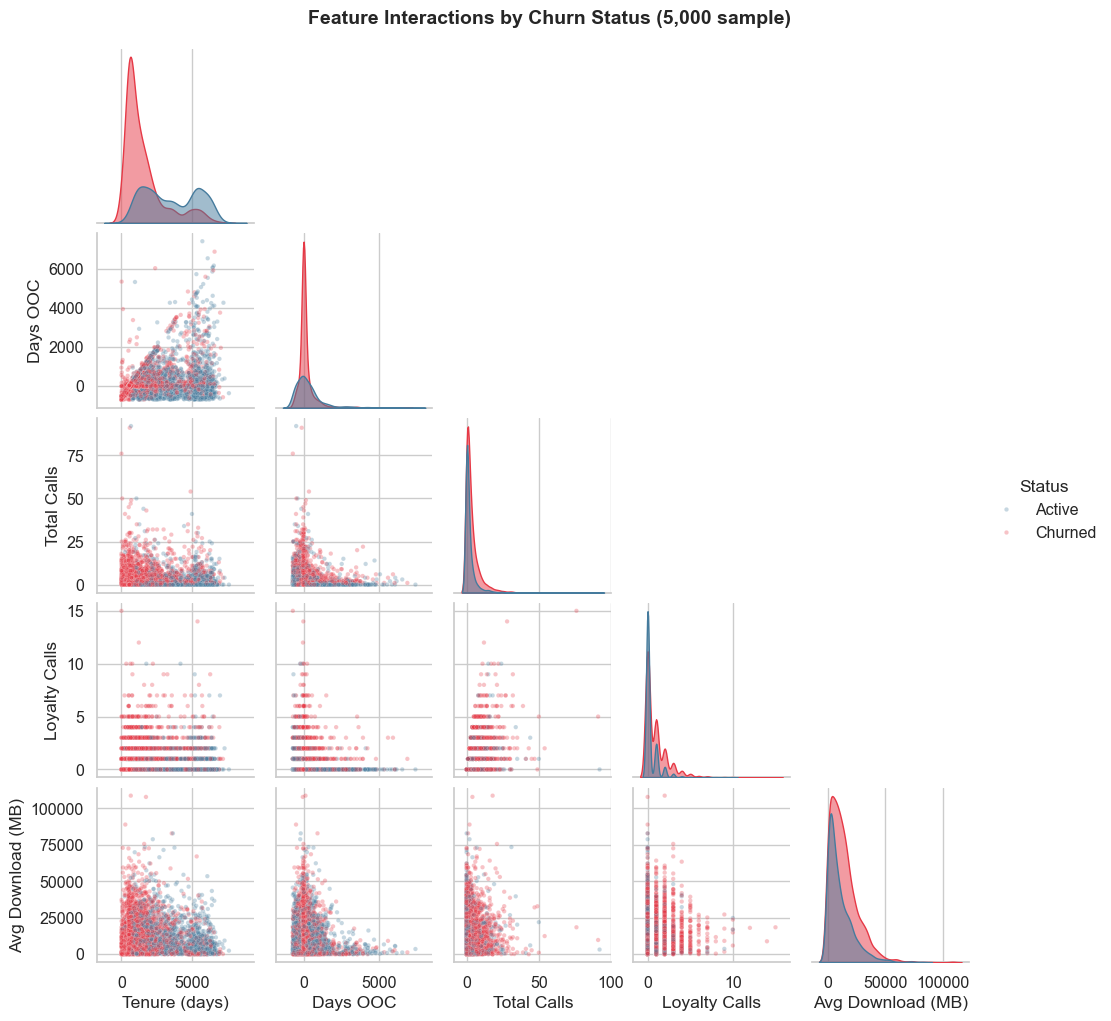

In [20]:

# ── Pairplot: visual overview of key feature interactions by churn ──
pair_cols = ['tenure_days', 'ooc_days', 'total_calls', 'loyalty_calls',
             'avg_download_mbs', 'churned']
pair_sample = (
    rich[pair_cols]
    .dropna()
    .sample(min(VIZ_SAMPLE, len(rich)), random_state=42)
)
pair_sample['Status'] = pair_sample['churned'].map(CHURN_LABEL_MAP)
pair_sample = pair_sample.rename(columns={
    'tenure_days':      'Tenure (days)',
    'ooc_days':         'Days OOC',
    'total_calls':      'Total Calls',
    'loyalty_calls':    'Loyalty Calls',
    'avg_download_mbs': 'Avg Download (MB)',
})

g = sns.pairplot(
    pair_sample,
    hue='Status',
    vars=['Tenure (days)', 'Days OOC', 'Total Calls', 'Loyalty Calls', 'Avg Download (MB)'],
    palette=PALETTE,
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kws={'alpha': 0.5},
    corner=True,
    height=2,
)
g.figure.suptitle(f'Feature Interactions by Churn Status ({VIZ_SAMPLE:,} sample)',
                   y=1.02, fontsize=14, fontweight='bold')
save_fig(g.figure, 'eda_pairplot')
plt.show()


In [21]:

# ── Resource cleanup ─────────────────────────────────────────────────────────
# Close the DuckDB connection now that all analysis is complete.
# This releases file locks and frees in-process memory.
con.close()
print('DuckDB connection closed.')


DuckDB connection closed.


---

## 12. Summary of Findings & Recommendations

### Key Risk Factors Identified

| # | Finding | Caveats | Recommended Action |
|---|---------|---------|-------------------|
| 1 | **≈65 % cumulative churn** (131 K / 203 K over 25 months); **≈4 % monthly** (operational rate) | Cumulative rate inflated by long window and rapid base growth. The 0.1 % monthly minimum is an incomplete final month artefact. | Use monthly rate for business reporting; cumulative rate only for addressable-opportunity sizing |
| 2 | **Tenure correlates with churn** (r = −0.49) | ⚠️ Partially a measurement artefact — churner tenure frozen at churn, actives accumulate to end of window. r = −0.49 is an *upper bound*. | Valid as a model feature in point-in-time design; do not quote as causal effect size |
| 3 | **Loyalty call → 77.6 % churn rate** vs 56.5 % baseline | ⚠️ **Reverse causality**: 41 % of loyalty calls occur on/after cease date. High rate reflects selection, not causation. | Use model to trigger intervention *before* loyalty escalation. Treat as treatment variable in modelling, not predictor. |
| 4 | **DD cancellation → ≈85–97 % churn** across OOC buckets | ⚠️ **Potential reverse causality**: DD may be cancelled as part of the cease process (auto-cancelled on departure, or customer cancels DD after deciding to leave). The timing of DD cancel relative to cease date is **not examined** in this EDA — a temporal analysis (DD cancel date vs. cease_placed_date) is needed before treating as a leading indicator. | Investigate DD cancel timing before deploying as real-time trigger. If DD cancel precedes cease by ≥14 days, flag for outreach. |
| 5 | **Speed gap**: mean 6.9 % (churned) vs 1.6 % (active) | Median gap is 0 % (churned) vs −6.6 % (active, i.e. over-delivered — common on FTTC short lines syncing above marketed tier). Mean driven by outlier tail. | Proactive network remediation for the underperforming tail, not the broad base |
| 6 | **FTTP technology** has highest churn rate by tech (≈93 %) | ⚠️ FTTP is the newest technology — short-tenure measurement bias disproportionately inflates its retrospective churn rate. **Cramér's V for Technology ↔ Churned = 0.041 (negligible)** — technology type explains almost none of the churn variation overall. The per-technology rates are driven by cohort composition, not technology per se. | Separate FTTP tenure effects from technology effects; do not treat technology as a strong churn driver without controlling for tenure |
| 7 | **Sales Channel ↔ Churned V = 0.366** (moderate) | ⚠️ Second strongest categorical association with churn, yet **no dedicated analysis performed in this EDA**. Channel may proxy for customer quality, contract terms, or price sensitivity. | Add churn-by-channel breakdown; investigate whether certain acquisition channels systematically attract higher-churn cohorts |
| 8 | **19-day median cease window** (placed → completed) | Based on 118 K of 146 K cease rows with valid dates. Does not account for **cease reversals** — ceases that were placed but never completed (successful saves). | Deploy save-desk workflow triggered by cease placement; also quantify cease reversal rate |
| 9 | **Seasonal patterns** in churn volume | Declining trend through 2024 may reflect base shrinkage, not improved retention. No formal seasonality test performed. | Align retention campaign budgets to seasonal peaks; consider STL decomposition |
| 10 | **Competitor deals** and **vague reasons** dominate exit reasons | "Vague Reason" coding (51.6 %) severely limits actionability. **Bereavement (6.3 %) and HomeMove (1.5 %)** are non-addressable life-event churn — they reduce the intervention-eligible pool by ≈10 K customers. | Improve reason coding at source; test counter-offers for "CompetitorDeals"; exclude Bereavement/HomeMove from retention targeting |
| 11 | **PCA shows class separation** in first 2 components | Variance explained depends on encoding choices (one-hot for nominal, ordinal for contract status). PCA assumes linear/continuous data — one-hot encoded categoricals violate this. FAMD would be more principled. | Treat as indicative, not definitive. Strong foundation for gradient-boosted tree or survival model which handle mixed types natively. |

### Data Considerations & Limitations

- **Observation period:** Aug 2022 – Sep 2024 (25 months, 26 monthly snapshots)
- **Cumulative vs operational churn:** The ≈65 % cumulative rate is NOT the monthly churn rate (≈4 %). The downstream modelling notebooks use point-in-time monthly snapshots where churn prevalence is ≈4–8 %. Do not quote the 65 % figure as a monthly or annual rate.
- **Edge-month artefact:** The first and last months of the observation window may have incomplete cease data, producing artificially low monthly churn rates (0.1 % in Sep 2024). Exclude these when quoting the operational range.
- **Retrospective analytical base:** The bivariate analysis joins each customer's latest pre-cease snapshot with churn labels. This creates a cross-section where different customers are measured at different calendar dates, which inflates correlations for time-accumulated features (tenure, call counts) and makes time-varying features non-comparable. The modelling notebooks correct this with temporal panel design.
- **Survivorship bias in tenure:** The "≈98 % churn under 2 years" finding is a compositional artefact of the retrospective view — churners' tenure is frozen at time of exit, while actives accumulate tenure to the end of the window. Only 1.4 % of active customers have tenure < 2 years. This is not an actionable at-risk probability.
- **Reverse causality (loyalty calls):** Loyalty calls and DD cancellations are partially consequences rather than causes of churn. The survival model (notebook 07) treats these as treatment/endogenous variables with explicit caveats.
- **Reverse causality (DD cancellation):** The timing of DD cancellation relative to cease-placed date has not been examined. The ≈85–97 % churn rate for DD-cancel customers could be a concurrent event rather than a leading indicator. A temporal analysis comparing `dd_cancel_date` to `cease_placed_date` is needed before deploying DD cancel as a real-time intervention trigger.
- **Cease reversals not quantified:** Churn is labelled on `cease_placed_date`, but not all cease orders may complete — some may be reversed by successful save interventions. This potentially overstates the true churn rate. The downstream modelling should examine `cease_completed_date IS NOT NULL` as the definitive churn label.
- **Voluntary vs involuntary / non-addressable churn:** The cease reasons include voluntary exits (CompetitorDeals 36 %), non-addressable life events (Bereavement 6.3 %, HomeMove 1.5 %), and involuntary disconnections (BadDebtDisconnect 0.1 %). These have fundamentally different drivers, intervention opportunities, and cost profiles. The addressable churn pool is materially smaller than the headline 131 K — Bereavement and HomeMove alone remove ≈10 K customers. Downstream modelling should either separate them or control for churn type.
- **Simpson's paradox (contract status):** In-contract customers show higher raw churn rates than out-of-contract in some views — this reflects cohort composition, not a causal effect of being in-contract.
- **Small cell sizes in heatmaps:** Interaction heatmaps (Contract Status × Technology, Tenure × Technology) contain cells with potentially very small N, producing unstable rate estimates (e.g. FTTP × Early Contract = 0 %). Cell counts should be consulted before drawing conclusions from individual cells.
- **Technology ↔ Churn negligible at aggregate level:** Despite FTTP showing ≈93 % per-technology churn, Cramér's V for Technology ↔ Churned = 0.041, indicating negligible overall association. The per-technology rates are confounded by tenure and market timing. Do not treat technology as a strong independent churn driver.
- **Sales Channel not analysed:** Sales Channel ↔ Churned V = 0.366 — the second strongest categorical association — is not explored in this EDA. This is a significant analytical gap that should be addressed in modelling.
- **Tenure KDE below-zero density:** The tenure distribution KDE shows apparent density below zero — this is a kernel smoothing artefact, not actual negative values. The data quality notebook (02) confirms 0 rows have `tenure_days < 0`. The Gaussian KDE bleeds density past the natural lower bound because many churned customers cluster near zero tenure.
- **Temporal split required:** Using future data to predict past would inflate accuracy — strict time-ordered splits applied in modelling
- **Duplicate cease handling:** 15,429 duplicate cease rows identified and deduplicated (first cease per customer retained for labelling)
- **Pre-cease snapshot anchoring:** For churned customers, features are drawn from the last available snapshot *on or before* the first cease date — preventing post-churn data leakage
- **Usage data quality:** Download/upload stored as text — type casting applied; some zero-usage days may reflect line faults rather than disengagement
- **No revenue/ARPU dimension:** This analysis lacks billing or revenue data. Churn is not equally costly across the base — high-ARPU churn has disproportionate business impact. Downstream modelling should incorporate customer lifetime value where available.